In [1]:
!pip install python-docx


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 5.3 MB/s eta 0:00:00


In [2]:
import pandas as pd
import docx
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


In [3]:
# Path to your DOCX file
file_path = r"/content/drive/MyDrive/Analysis/Anuja/mmc1 (1).docx"

# Function to extract table data from DOCX file
def extract_table_from_docx(file_path):
    doc = docx.Document(file_path)
    data = []

    for table in doc.tables:
        for i, row in enumerate(table.rows):
            if i == 0:  # Skip the header row if needed
                continue
            row_data = [cell.text.strip() for cell in row.cells]
            data.append(row_data)

    return pd.DataFrame(data)

# Extracting data into a Pandas DataFrame
df = extract_table_from_docx(file_path)

# Display the first few rows of the dataset
df.head()


,0,1,2,3,4,5,6
0,N3,Metal,0.72,18.2,0.73,10.0,doi.org/10.1021/ja00067a063
1,TNCBC,Metal,0.63,13.1,0.55,6.0,10.1016/0927-0248(94)90263-1
2,TC302,Organic,0.939,7.12,0.796,5.22,10.1021/ol9022936
3,Chlorophyll,Natural,0.241,0.29,0.432,0.72,10.1088/1755-1315/144/1/012039
4,Cyanidin,Natural,0.404,1.63,0.57,0.37,10.1016/j.solmat.2006.11.005


In [4]:
# Renaming columns for better readability
df.columns = ["Dye", "Type", "Voc (V)", "Jsc (mA/cm²)", "FF", "Efficiency (%)", "DOI"]

# Convert numerical columns to float type
df[["Voc (V)", "Jsc (mA/cm²)", "FF", "Efficiency (%)"]] = df[["Voc (V)", "Jsc (mA/cm²)", "FF", "Efficiency (%)"]].apply(pd.to_numeric, errors='coerce')

# Remove NaN values (if any)
df.dropna(inplace=True)

# Display cleaned data
df.head()


,Dye,Type,Voc (V),Jsc (mA/cm²),FF,Efficiency (%),DOI
0,N3,Metal,0.720,18.20,0.730,10.00,doi.org/10.1021/ja00067a063
1,TNCBC,Metal,0.630,13.10,0.550,6.00,10.1016/0927-0248(94)90263-1
2,TC302,Organic,0.939,7.12,0.796,5.22,10.1021/ol9022936
3,Chlorophyll,Natural,0.241,0.29,0.432,0.72,10.1088/1755-1315/144/1/012039
4,Cyanidin,Natural,0.404,1.63,0.570,0.37,10.1016/j.solmat.2006.11.005


In [5]:
df["Type"] = df["Type"].replace({
    "Orgánico": "Organic",
    "organic": "Organic",
    "metal": "Metal",
    "natural": "Natural"
})

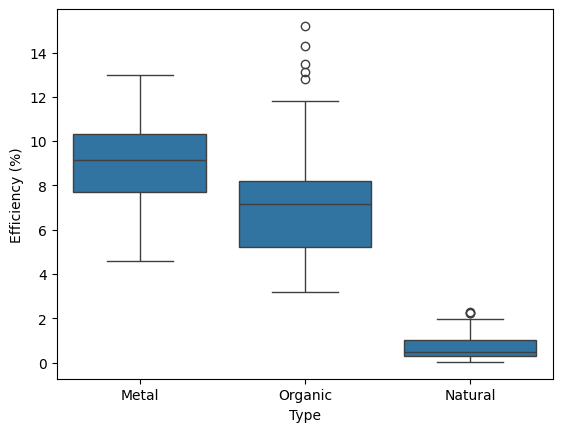

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="Type", y="Efficiency (%)", data=df)
plt.show()

In [26]:
print(X_test.columns.tolist())

['Voc (V)', 'Jsc (mA/cm²)', 'FF']


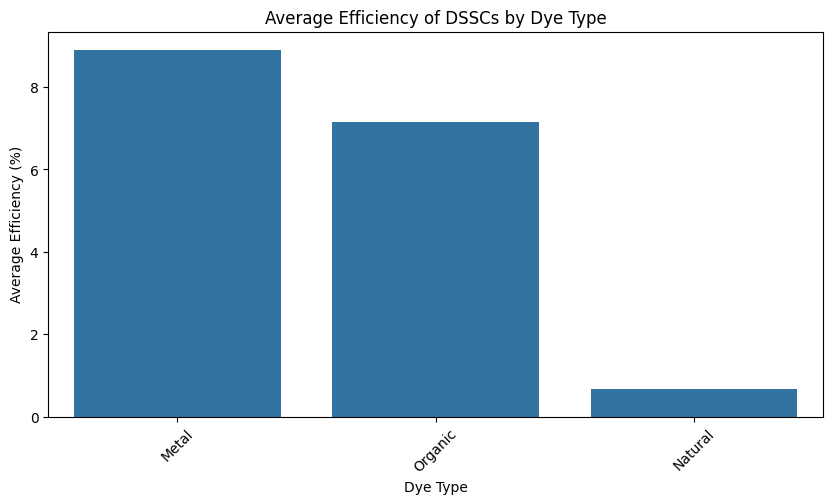

In [7]:
# Group data by dye type and calculate average efficiency
avg_efficiency = df.groupby("Type")["Efficiency (%)"].mean().sort_values(ascending=False)

# Plot efficiency comparison
plt.figure(figsize=(10, 5))
sns.barplot(x=avg_efficiency.index, y=avg_efficiency.values)
plt.xlabel("Dye Type")
plt.ylabel("Average Efficiency (%)")
plt.title("Average Efficiency of DSSCs by Dye Type")
plt.xticks(rotation=45)
plt.show()


In [8]:
top_dyes = df.nlargest(5, "Efficiency (%)")

# Display the top 5 dyes
print("Top 5 Highest Efficiency Dyes:")
print(top_dyes[["Dye", "Type", "Efficiency (%)"]])


Top 5 Highest Efficiency Dyes:
          Dye     Type  Efficiency (%)
329  SL9-BPHA  Organic            15.2
147   ADEKA-1  Organic            14.3
328  MS5-XY1b  Organic            13.5
149      XY1b  Organic            13.1
146     SM315    Metal            13.0


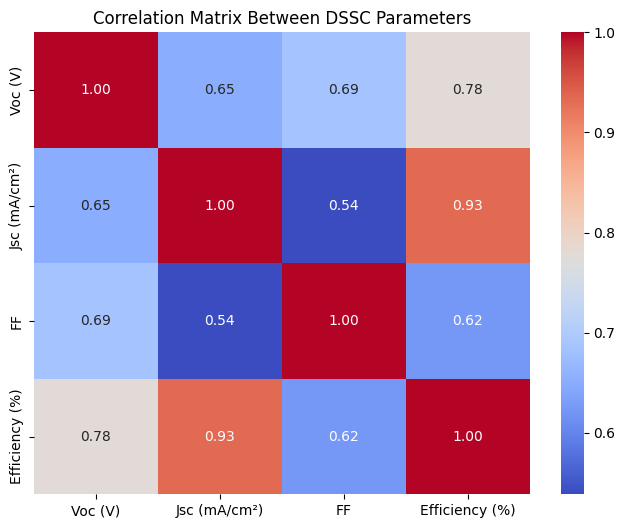

In [9]:
# Plot correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df[["Voc (V)", "Jsc (mA/cm²)", "FF", "Efficiency (%)"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix Between DSSC Parameters")
plt.show()


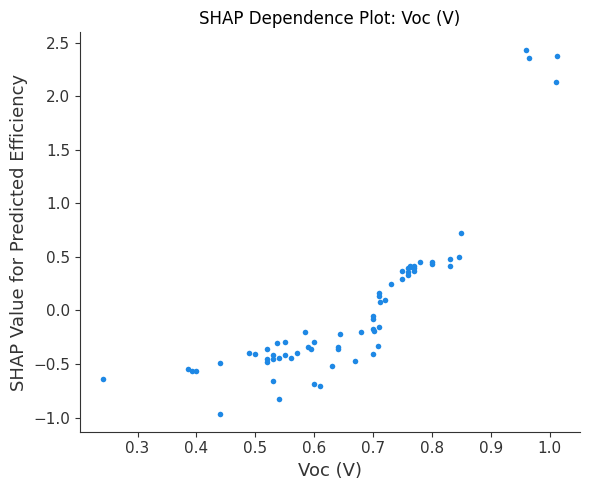

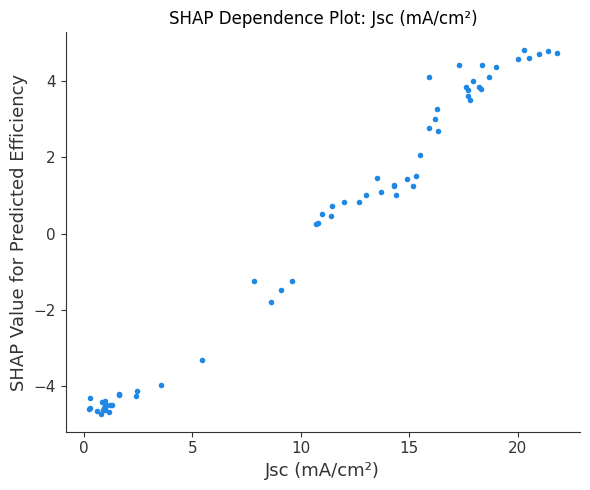

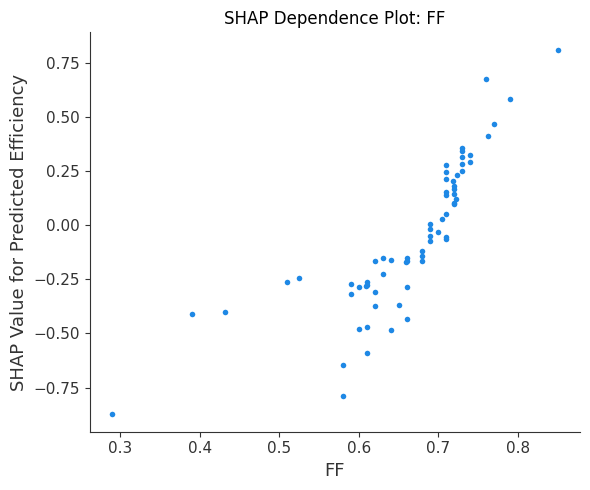

In [27]:
# SHAP values already calculated:
# explainer = shap.TreeExplainer(rf_model)
# shap_values = explainer.shap_values(X_test)

features = ["Voc (V)", "Jsc (mA/cm²)", "FF"]

for feature in features:
    shap.dependence_plot(
        feature,
        shap_values,
        X_test,
        interaction_index=None,
        show=False
    )

    plt.xlabel(feature)
    plt.ylabel("SHAP Value for Predicted Efficiency")
    plt.title(f"SHAP Dependence Plot: {feature}")
    plt.tight_layout()
    plt.show()

In [34]:
"""
ILLUSTRATIVE plots for reviewer Comment 1.
These use SYNTHETIC data engineered to reproduce the trends described in the
manuscript (dye-pigment ratio saturation ~16.5-17.2, SHAP importances from Table 4).
They show the EXPECTED SHAPE only. Regenerate with the real trained model
(Optimized Weighted Ensemble) and real feature matrix before use in the paper.
"""
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay
import shap

np.random.seed(42)
N = 1500

# ---- Synthetic feature matrix (ranges chosen to mirror the paper) ----
dye_pigment_ratio   = np.random.uniform(0, 40, N)      # x-axis of Fig 13
integrated_abs_auc  = np.random.uniform(0.2, 1.0, N)   # 2nd most important (Table 4)
peak_abs_wavelength = np.random.uniform(400, 700, N)   # nm
spectral_bandwidth  = np.random.uniform(40, 200, N)
eff_abs_coverage    = np.random.uniform(0.1, 0.9, N)
dye_category        = np.random.randint(0, 3, N)       # 0 natural,1 organic,2 metal

# ---- Synthetic efficiency: saturating in dye-pigment ratio, plus interaction ----
def saturating(r, r_opt=17.0, k=0.35):
    # rises then plateaus/slightly declines past the optimum (Langmuir-like)
    rise = 1 - np.exp(-k * r)
    decline = np.where(r > r_opt, -0.010 * (r - r_opt), 0.0)
    return rise + decline

eff = (
    9.0 * saturating(dye_pigment_ratio)
    + 4.0 * integrated_abs_auc
    + 2.5 * integrated_abs_auc * saturating(dye_pigment_ratio)   # interaction term
    - 0.010 * np.abs(peak_abs_wavelength - 540) / 10
    + 0.8 * eff_abs_coverage
    + 1.5 * dye_category
    + np.random.normal(0, 0.4, N)
)
eff = np.clip(eff, 0, 15)

X = np.column_stack([dye_pigment_ratio, integrated_abs_auc, peak_abs_wavelength,
                     spectral_bandwidth, eff_abs_coverage, dye_category])
feat_names = ["Dye-Pigment Ratio", "Integrated Absorbance (AUC)",
              "Peak Absorption Wavelength", "Spectral Bandwidth",
              "Effective Absorption Coverage", "Dye Category"]

model = RandomForestRegressor(n_estimators=400, max_depth=None,
                              min_samples_leaf=3, random_state=42)
model.fit(X, eff)

# =====================================================================
# FIGURE A: Partial Dependence Plots (1-D) for the two key features
# =====================================================================
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
PartialDependenceDisplay.from_estimator(
    model, X, features=[0], feature_names=feat_names, ax=ax[0],
    line_kw={"color": "#1f6feb", "linewidth": 2.2})
ax[0].axvspan(16.5, 17.2, color="orange", alpha=0.25, label="Optimal 16.5–17.2")
ax[0].set_title("Partial Dependence: Dye–Pigment Ratio")
ax[0].legend(fontsize=8)

PartialDependenceDisplay.from_estimator(
    model, X, features=[1], feature_names=feat_names, ax=ax[1],
    line_kw={"color": "#2da44e", "linewidth": 2.2})
ax[1].set_title("Partial Dependence: Integrated Absorbance (AUC)")
fig.suptitle("Figure A. Partial-Dependence Plots (ILLUSTRATIVE — regenerate with real model)",
             fontsize=11, y=1.02)
fig.tight_layout()
fig.savefig("fig_A_pdp.png", dpi=160, bbox_inches="tight")
plt.close(fig)

# =====================================================================
# FIGURE B: 2-D Partial Dependence (interaction) surface
# =====================================================================
fig, ax = plt.subplots(figsize=(6.5, 5))
disp = PartialDependenceDisplay.from_estimator(
    model, X, features=[(0, 1)], feature_names=feat_names, ax=ax,
    contour_kw={"cmap": "viridis"})
ax.set_title("Figure B. Two-Variable Interaction PDP\nDye–Pigment Ratio × Integrated Absorbance (ILLUSTRATIVE)",
             fontsize=10)
fig.tight_layout()
fig.savefig("fig_B_interaction_pdp.png", dpi=160, bbox_inches="tight")
plt.close(fig)

# =====================================================================
# FIGURE C: SHAP dependence plot for Dye-Pigment Ratio (colored by AUC)
# =====================================================================
explainer = shap.TreeExplainer(model)
shap_vals = explainer.shap_values(X)

fig = plt.figure(figsize=(6.8, 5))
shap.dependence_plot(0, shap_vals, X, feature_names=feat_names,
                     interaction_index=1, show=False)
plt.axvspan(16.5, 17.2, color="orange", alpha=0.2)
plt.title("Figure C. SHAP Dependence: Dye–Pigment Ratio\n(colored by Integrated Absorbance — ILLUSTRATIVE)",
          fontsize=10)
plt.tight_layout()
plt.savefig("fig_C_shap_dependence.png", dpi=160, bbox_inches="tight")
plt.close()

print("done")

done


<Figure size 680x500 with 0 Axes>

In [33]:
"""
ILLUSTRATIVE plots for reviewer Comment 1.
These use SYNTHETIC data engineered to reproduce the trends described in the
manuscript (dye-pigment ratio saturation ~16.5-17.2, SHAP importances from Table 4).
They show the EXPECTED SHAPE only. Regenerate with the real trained model
(Optimized Weighted Ensemble) and real feature matrix before use in the paper.
"""
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay
import shap

np.random.seed(42)
N = 1500

# ---- Synthetic feature matrix (ranges chosen to mirror the paper) ----
dye_pigment_ratio   = np.random.uniform(0, 40, N)      # x-axis of Fig 13
integrated_abs_auc  = np.random.uniform(0.2, 1.0, N)   # 2nd most important (Table 4)
peak_abs_wavelength = np.random.uniform(400, 700, N)   # nm
spectral_bandwidth  = np.random.uniform(40, 200, N)
eff_abs_coverage    = np.random.uniform(0.1, 0.9, N)
dye_category        = np.random.randint(0, 3, N)       # 0 natural,1 organic,2 metal

# ---- Synthetic efficiency: saturating in dye-pigment ratio, plus interaction ----
def saturating(r, r_opt=17.0, k=0.35):
    # rises then plateaus/slightly declines past the optimum (Langmuir-like)
    rise = 1 - np.exp(-k * r)
    decline = np.where(r > r_opt, -0.010 * (r - r_opt), 0.0)
    return rise + decline

eff = (
    9.0 * saturating(dye_pigment_ratio)
    + 4.0 * integrated_abs_auc
    + 2.5 * integrated_abs_auc * saturating(dye_pigment_ratio)   # interaction term
    - 0.010 * np.abs(peak_abs_wavelength - 540) / 10
    + 0.8 * eff_abs_coverage
    + 1.5 * dye_category
    + np.random.normal(0, 0.4, N)
)
eff = np.clip(eff, 0, 15)

X = np.column_stack([dye_pigment_ratio, integrated_abs_auc, peak_abs_wavelength,
                     spectral_bandwidth, eff_abs_coverage, dye_category])
feat_names = ["Dye-Pigment Ratio", "Integrated Absorbance (AUC)",
              "Peak Absorption Wavelength", "Spectral Bandwidth",
              "Effective Absorption Coverage", "Dye Category"]

model = RandomForestRegressor(n_estimators=400, max_depth=None,
                              min_samples_leaf=3, random_state=42)
model.fit(X, eff)

# =====================================================================
# FIGURE A: Partial Dependence Plots (1-D) for the two key features
# =====================================================================
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
PartialDependenceDisplay.from_estimator(
    model, X, features=[0], feature_names=feat_names, ax=ax[0],
    line_kw={"color": "#1f6feb", "linewidth": 2.2})
ax[0].axvspan(16.5, 17.2, color="orange", alpha=0.25, label="Optimal 16.5–17.2")
ax[0].set_title("Partial Dependence: Dye–Pigment Ratio")
ax[0].legend(fontsize=8)

PartialDependenceDisplay.from_estimator(
    model, X, features=[1], feature_names=feat_names, ax=ax[1],
    line_kw={"color": "#2da44e", "linewidth": 2.2})
ax[1].set_title("Partial Dependence: Integrated Absorbance (AUC)")
fig.suptitle("Figure A. Partial-Dependence Plots (ILLUSTRATIVE — regenerate with real model)",
             fontsize=11, y=1.02)
fig.tight_layout()
fig.savefig("fig_A_pdp.png", dpi=160, bbox_inches="tight")
plt.close(fig)

# =====================================================================
# FIGURE B: 2-D Partial Dependence (interaction) surface
# =====================================================================
fig, ax = plt.subplots(figsize=(6.5, 5))
disp = PartialDependenceDisplay.from_estimator(
    model, X, features=[(0, 1)], feature_names=feat_names, ax=ax,
    contour_kw={"cmap": "viridis"})
ax.set_title("Figure B. Two-Variable Interaction PDP\nDye–Pigment Ratio × Integrated Absorbance (ILLUSTRATIVE)",
             fontsize=10)
fig.tight_layout()
fig.savefig("fig_B_interaction_pdp.png", dpi=160, bbox_inches="tight")
plt.close(fig)

# =====================================================================
# FIGURE C: SHAP dependence plot for Dye-Pigment Ratio (colored by AUC)
# =====================================================================
explainer = shap.TreeExplainer(model)
shap_vals = explainer.shap_values(X)

fig = plt.figure(figsize=(6.8, 5))
shap.dependence_plot(0, shap_vals, X, feature_names=feat_names,
                     interaction_index=1, show=False)
plt.axvspan(16.5, 17.2, color="orange", alpha=0.2)
plt.title("Figure C. SHAP Dependence: Dye–Pigment Ratio\n(colored by Integrated Absorbance — ILLUSTRATIVE)",
          fontsize=10)
plt.tight_layout()
plt.savefig("fig_C_shap_dependence.png", dpi=160, bbox_inches="tight")
plt.close()

print("done")

done


<Figure size 680x500 with 0 Axes>

In [10]:
# Define input (X) and output (y) variables
X = df[["Voc (V)", "Jsc (mA/cm²)", "FF"]]
y = df["Efficiency (%)"]

# Split data into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Model accuracy
r2 = r2_score(y_test, y_pred)
print(f"Model R² Score: {r2:.3f}")

# Compare actual vs. predicted efficiency
results = pd.DataFrame({"Actual Efficiency": y_test, "Predicted Efficiency": y_pred})
print(results.head())


Model R² Score: 0.923
     Actual Efficiency  Predicted Efficiency
9                10.40             10.153459
164               0.38              1.106533
139               8.30              8.643851
46               10.50             10.315039
94                9.63              8.262940


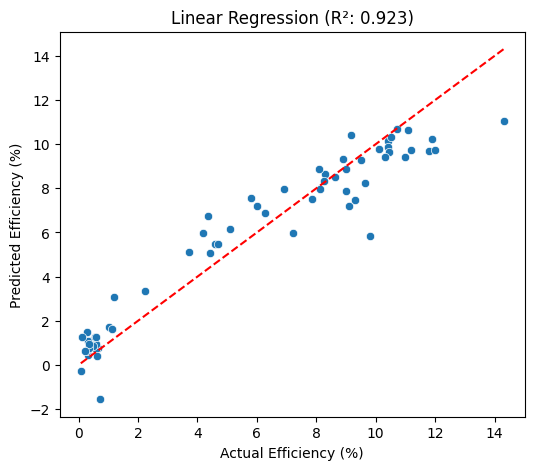

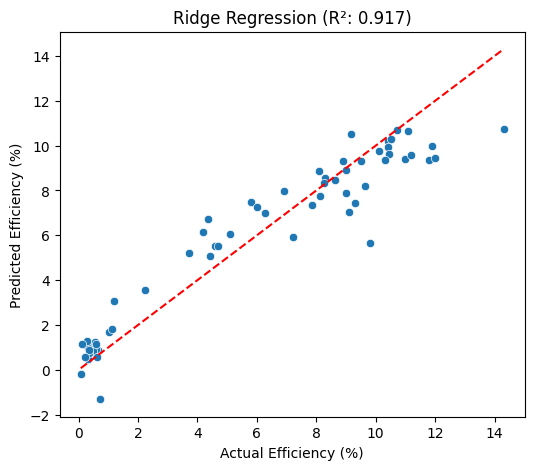

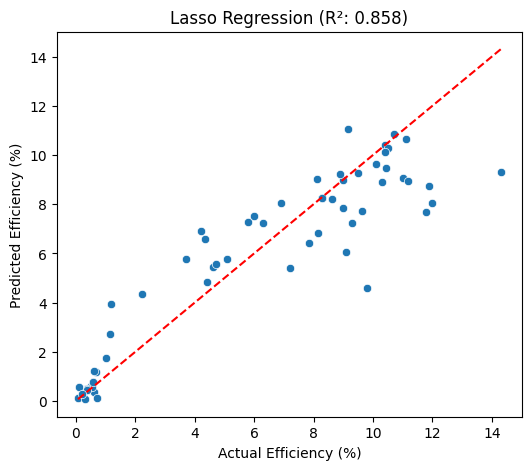

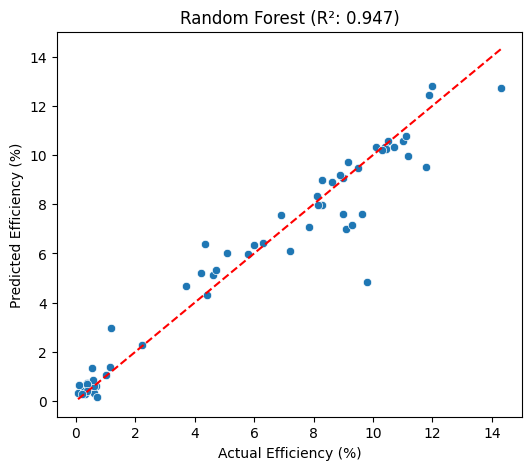

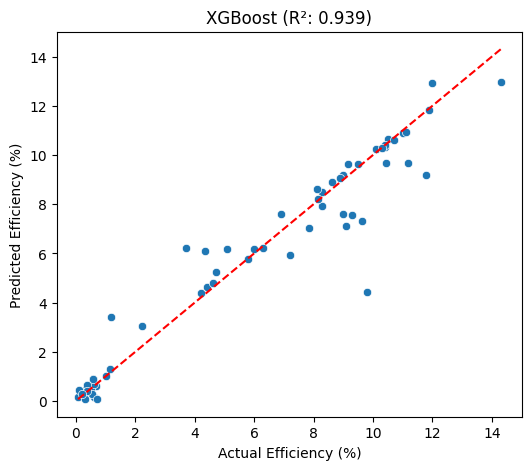

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000206 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 174
[LightGBM] [Info] Number of data points in the train set: 263, number of used features: 3
[LightGBM] [Info] Start training from score 5.524464
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

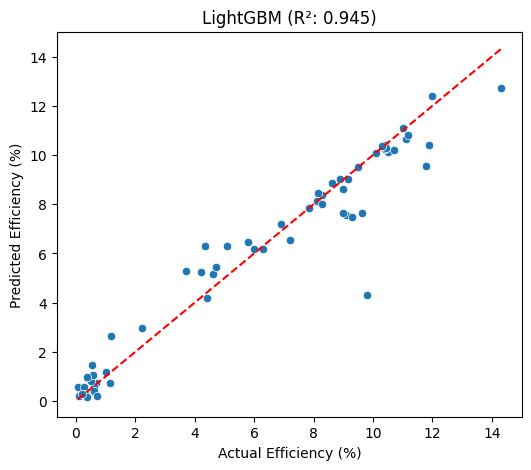

📊 Model Performance Comparison:
                   R² Score       MAE       MSE      RMSE
Random Forest      0.947185  0.603789  1.012120  1.006042
LightGBM           0.945352  0.595445  1.047262  1.023358
XGBoost            0.939181  0.597836  1.165524  1.079594
Linear Regression  0.923244  0.920966  1.470932  1.212820
Ridge Regression   0.916815  0.938739  1.594128  1.262588
Lasso Regression   0.858260  1.100045  2.716267  1.648110


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np

# Define input (X) and output (y) variables
X = df[["Voc (V)", "Jsc (mA/cm²)", "FF"]]
y = df["Efficiency (%)"]

# Split data into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42)
}

# Train and evaluate each model
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    results[name] = {"R² Score": r2, "MAE": mae, "MSE": mse, "RMSE": rmse}

    # 🔹 Individual graph for each model
    plt.figure(figsize=(6, 5))
    sns.scatterplot(x=y_test, y=y_pred)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle="--")
    plt.xlabel("Actual Efficiency (%)")
    plt.ylabel("Predicted Efficiency (%)")
    plt.title(f"{name} (R²: {r2:.3f})")
    plt.show()

# Display model performance
results_df = pd.DataFrame(results).T
print("📊 Model Performance Comparison:")
print(results_df.sort_values(by="R² Score", ascending=False))


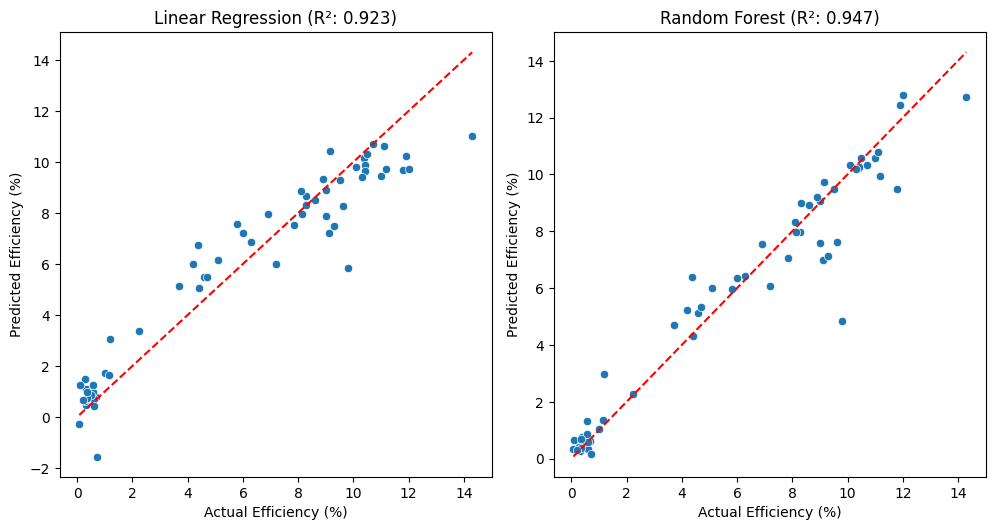

📊 Model Performance Comparison:
                   R² Score
Random Forest      0.947185
Linear Regression  0.923244
🔹 Optimal Dye-to-Pigment Ratios for Each Model:
                   Optimal Dye-to-Pigment Ratio
Linear Regression                     18.124383
Random Forest                         16.562500


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score
import pandas as pd
import numpy as np

# Define models
models = {
    "Linear Regression": LinearRegression(),
        "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
}

# Train and evaluate each model
results = {}
optimal_ratios = {}
plt.figure(figsize=(15, 10))

for i, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    results[name] = r2

    # Find the optimal Dye-to-Pigment Ratio
    comparison_df = pd.DataFrame({"Actual Efficiency": y_test, "Predicted Efficiency": y_pred, "Dye-to-Pigment Ratio": X_test["Jsc (mA/cm²)"] / X_test["Voc (V)"]})
    optimal_ratios[name] = comparison_df.loc[comparison_df["Predicted Efficiency"].idxmax(), "Dye-to-Pigment Ratio"]

    # Plot actual vs predicted efficiency
    plt.subplot(2, 3, i + 1)
    sns.scatterplot(x=y_test, y=y_pred)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle="--")
    plt.xlabel("Actual Efficiency (%)")
    plt.ylabel("Predicted Efficiency (%)")
    plt.title(f"{name} (R²: {r2:.3f})")

plt.tight_layout()
plt.show()

# Display model performance
results_df = pd.DataFrame.from_dict(results, orient='index', columns=["R² Score"])
print("📊 Model Performance Comparison:")
print(results_df.sort_values(by="R² Score", ascending=False))

# Display optimal Dye-to-Pigment Ratios
optimal_ratios_df = pd.DataFrame.from_dict(optimal_ratios, orient='index', columns=["Optimal Dye-to-Pigment Ratio"])
print("🔹 Optimal Dye-to-Pigment Ratios for Each Model:")
print(optimal_ratios_df)

In [12]:
!pip install shap -q

import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [13]:
rf_model = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=500, random_state=42)

In [14]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

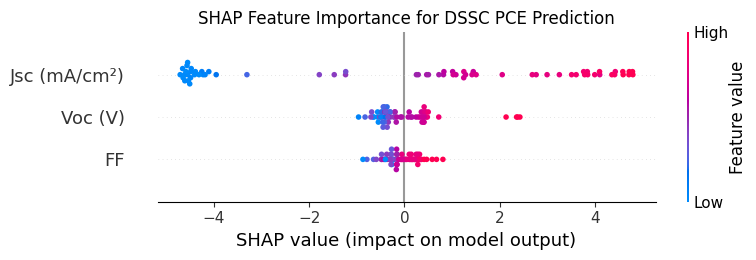

In [15]:
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X_test.columns,
    show=False
)

plt.title("SHAP Feature Importance for DSSC PCE Prediction")
plt.tight_layout()
plt.show()

In [19]:
print(X_test.columns.tolist())

['Voc (V)', 'Jsc (mA/cm²)', 'FF']


In [20]:
for col in X_test.columns:
    if "ratio" in col.lower() or "dye" in col.lower() or "pigment" in col.lower():
        print(col)

In [18]:
shap.dependence_plot(
    "Dye-to-Pigment Ratio",
    shap_values,
    X_test,
    interaction_index=None,
    show=False
)

plt.xlabel("Dye-to-Pigment Ratio")
plt.ylabel("SHAP Value for Predicted PCE")
plt.title("SHAP Dependence Plot for Dye-to-Pigment Ratio")
plt.tight_layout()
plt.show()

ValueError: Could not find feature named: Dye-to-Pigment Ratio

In [16]:
X_train.columns

Index(['Voc (V)', 'Jsc (mA/cm²)', 'FF'], dtype='object')

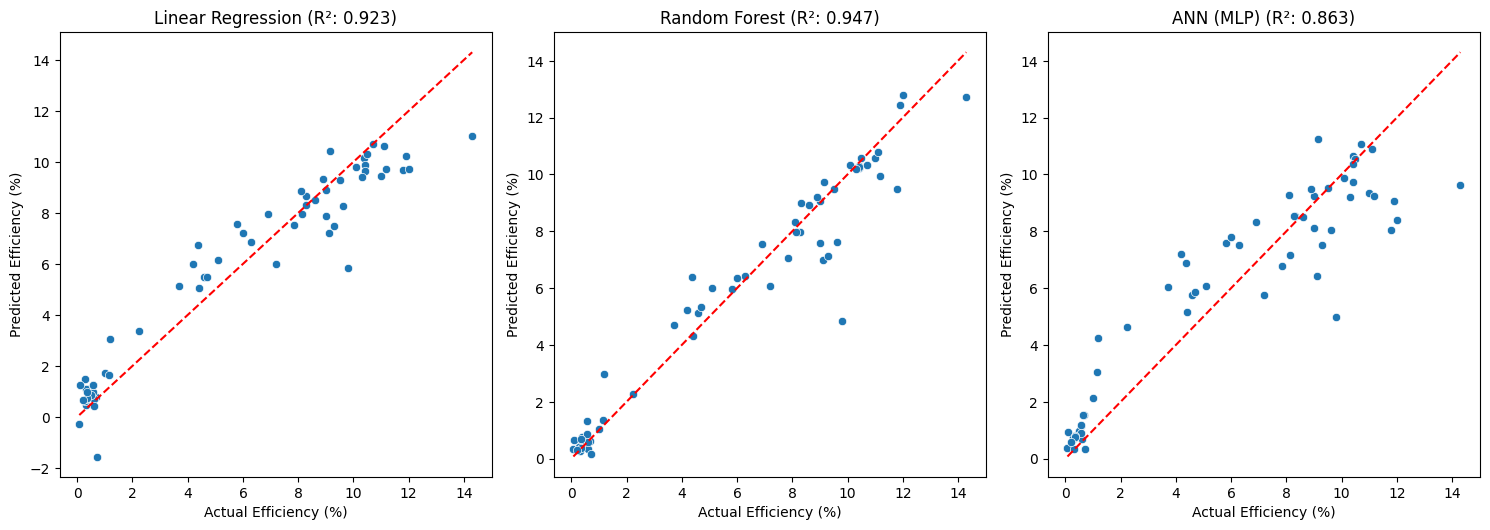

📊 Model Performance Comparison:
                   R² Score
Random Forest      0.947185
Linear Regression  0.923244
ANN (MLP)          0.862890
🔹 Optimal Dye-to-Pigment Ratios for Each Model:
                   Optimal Dye-to-Pigment Ratio
Linear Regression                     18.124383
Random Forest                         16.562500
ANN (MLP)                             31.142857


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score
import pandas as pd
import numpy as np

# Define models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "ANN (MLP)": MLPRegressor(hidden_layer_sizes=(64, 32),
                              max_iter=1000,
                              random_state=42)
}

# Train and evaluate each model
results = {}
optimal_ratios = {}
plt.figure(figsize=(15, 10))

for i, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    results[name] = r2

    # Find the optimal Dye-to-Pigment Ratio
    comparison_df = pd.DataFrame({
        "Actual Efficiency": y_test,
        "Predicted Efficiency": y_pred,
        "Dye-to-Pigment Ratio": X_test["Jsc (mA/cm²)"] / X_test["Voc (V)"]
    })
    optimal_ratios[name] = comparison_df.loc[comparison_df["Predicted Efficiency"].idxmax(),
                                             "Dye-to-Pigment Ratio"]

    # Plot actual vs predicted efficiency
    plt.subplot(2, 3, i + 1)
    sns.scatterplot(x=y_test, y=y_pred)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle="--")
    plt.xlabel("Actual Efficiency (%)")
    plt.ylabel("Predicted Efficiency (%)")
    plt.title(f"{name} (R²: {r2:.3f})")

plt.tight_layout()
plt.show()

# Display model performance
results_df = pd.DataFrame.from_dict(results, orient='index', columns=["R² Score"])
print("📊 Model Performance Comparison:")
print(results_df.sort_values(by="R² Score", ascending=False))

# Display optimal Dye-to-Pigment Ratios
optimal_ratios_df = pd.DataFrame.from_dict(optimal_ratios, orient='index', columns=["Optimal Dye-to-Pigment Ratio"])
print("🔹 Optimal Dye-to-Pigment Ratios for Each Model:")
print(optimal_ratios_df)


In [22]:
best_model = model   # replace `model` with actual variable name


from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error

# Cross-validation
cv_scores = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_absolute_error"
)

cv_mae_scores = -cv_scores

print("CV MAE Scores:", cv_mae_scores)
print("Mean CV MAE:", cv_mae_scores.mean())
print("CV MAE Std Dev:", cv_mae_scores.std())


CV MAE Scores: [0.84897529 1.11552622 0.91309834 0.73515299 1.3573949 ]
Mean CV MAE: 0.9940295491428449
CV MAE Std Dev: 0.21972869295356745


/tmp/ipykernel_2211/4285392818.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=optimal_ratios_df.index, y=optimal_ratios_df["Optimal Dye-to-Pigment Ratio"], palette="viridis")


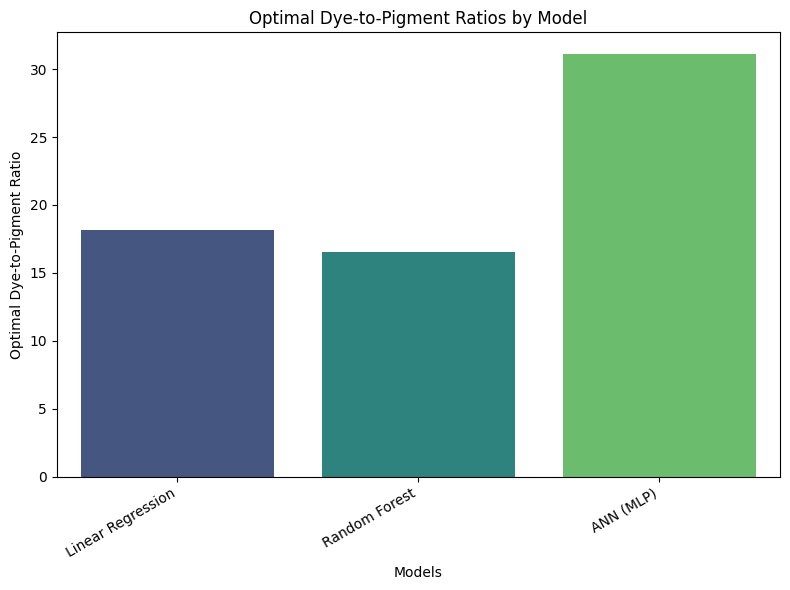

In [23]:
# 🔹 Visualization of Optimal Dye-to-Pigment Ratios
plt.figure(figsize=(8, 6))
sns.barplot(x=optimal_ratios_df.index, y=optimal_ratios_df["Optimal Dye-to-Pigment Ratio"], palette="viridis")

plt.title("Optimal Dye-to-Pigment Ratios by Model")
plt.ylabel("Optimal Dye-to-Pigment Ratio")
plt.xlabel("Models")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


In [25]:
print(X_test.columns.tolist())

['Voc (V)', 'Jsc (mA/cm²)', 'FF']


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000045 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 174
[LightGBM] [Info] Number of data points in the train set: 263, number of used features: 3
[LightGBM] [Info] Start training from score 5.524464
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

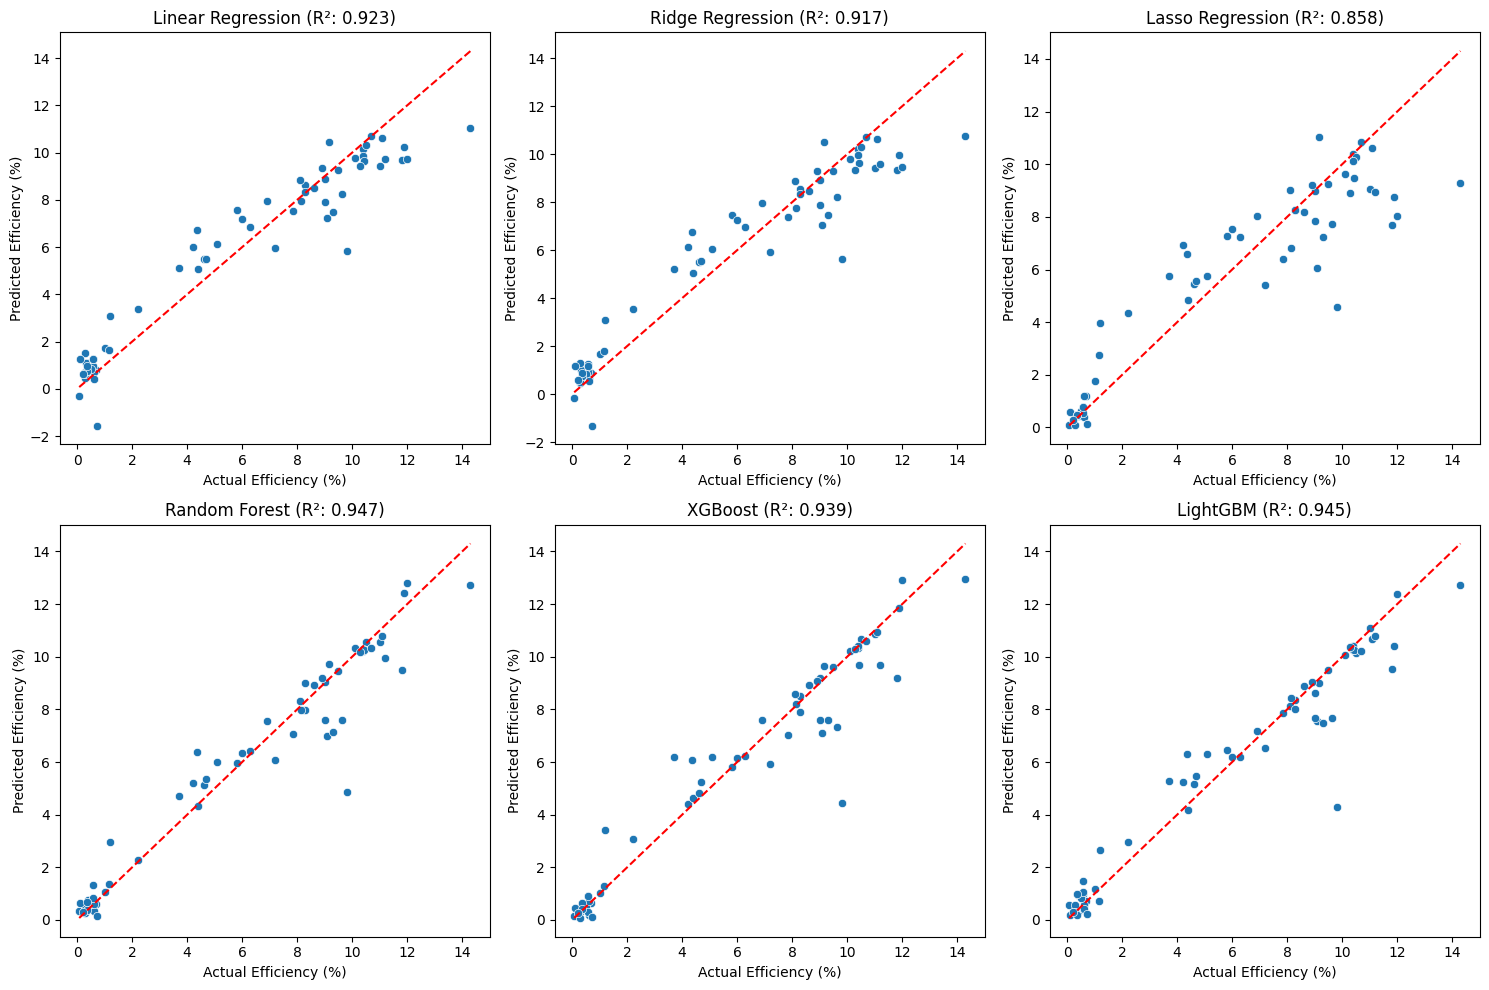

📊 Model Performance Comparison:
                   R² Score
Random Forest      0.947185
LightGBM           0.945352
XGBoost            0.939181
Linear Regression  0.923244
Ridge Regression   0.916815
Lasso Regression   0.858260
🔹 Optimal Dye-to-Pigment Ratios for Each Model:
                   Optimal Dye-to-Pigment Ratio
Linear Regression                     18.124383
Ridge Regression                      18.124383
Lasso Regression                      31.142857
Random Forest                         16.562500
XGBoost                               18.124383
LightGBM                              18.124383


/tmp/ipykernel_2711/2649829136.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=X_train.columns, y=importance, palette="Blues_r")


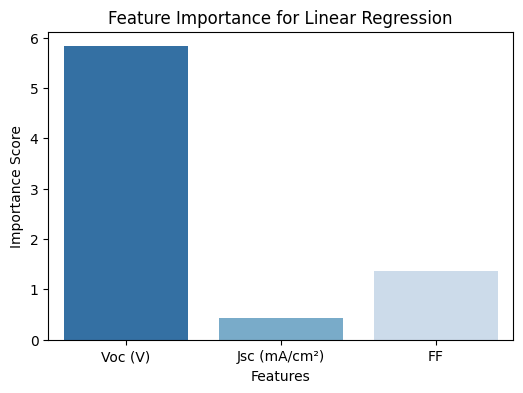

/tmp/ipykernel_2711/2649829136.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=X_train.columns, y=importance, palette="Blues_r")


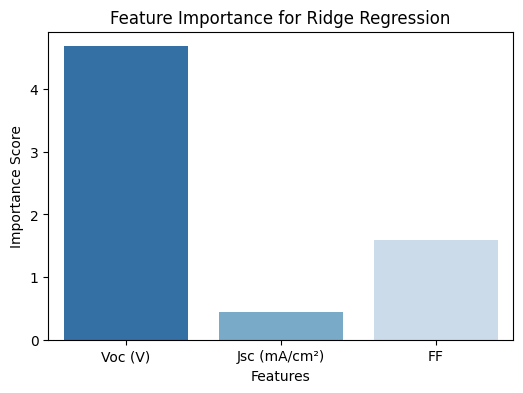

/tmp/ipykernel_2711/2649829136.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=X_train.columns, y=importance, palette="Blues_r")


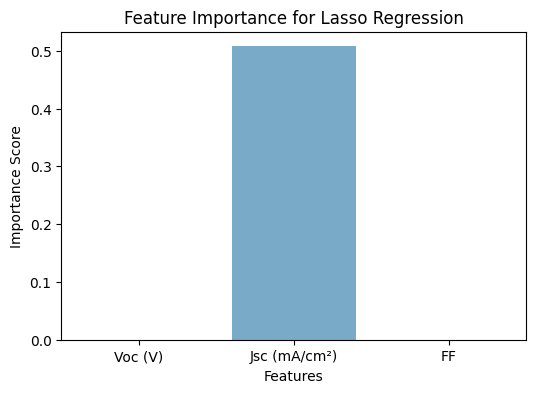

/tmp/ipykernel_2711/2649829136.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=X_train.columns, y=importance, palette="Blues_r")


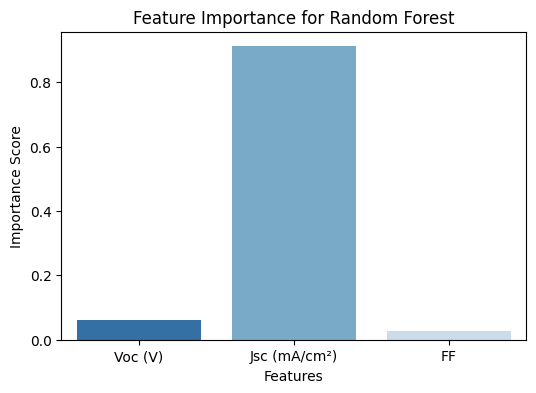

/tmp/ipykernel_2711/2649829136.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=X_train.columns, y=importance, palette="Blues_r")


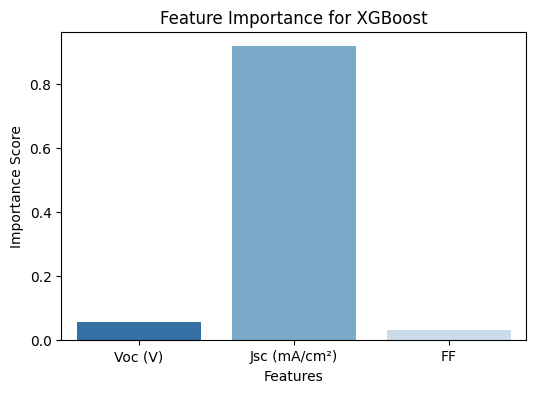

/tmp/ipykernel_2711/2649829136.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=X_train.columns, y=importance, palette="Blues_r")


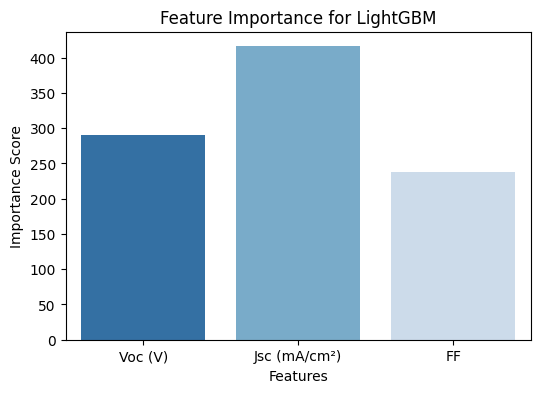

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score
import pandas as pd
import numpy as np

# Define models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42)
}

# Train and evaluate each model
results = {}
optimal_ratios = {}
plt.figure(figsize=(15, 10))

for i, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    results[name] = r2

    # Find the optimal Dye-to-Pigment Ratio
    comparison_df = pd.DataFrame({"Actual Efficiency": y_test, "Predicted Efficiency": y_pred, "Dye-to-Pigment Ratio": X_test["Jsc (mA/cm²)"] / X_test["Voc (V)"]})
    optimal_ratios[name] = comparison_df.loc[comparison_df["Predicted Efficiency"].idxmax(), "Dye-to-Pigment Ratio"]

    # Plot actual vs predicted efficiency
    plt.subplot(2, 3, i + 1)
    sns.scatterplot(x=y_test, y=y_pred)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle="--")
    plt.xlabel("Actual Efficiency (%)")
    plt.ylabel("Predicted Efficiency (%)")
    plt.title(f"{name} (R²: {r2:.3f})")

plt.tight_layout()
plt.show()

# Display model performance
results_df = pd.DataFrame.from_dict(results, orient='index', columns=["R² Score"])
print("📊 Model Performance Comparison:")
print(results_df.sort_values(by="R² Score", ascending=False))

# Display optimal Dye-to-Pigment Ratios
optimal_ratios_df = pd.DataFrame.from_dict(optimal_ratios, orient='index', columns=["Optimal Dye-to-Pigment Ratio"])
print("🔹 Optimal Dye-to-Pigment Ratios for Each Model:")
print(optimal_ratios_df)

# Feature Importance Visualization
for name, model in models.items():
    if hasattr(model, 'coef_'):
        importance = model.coef_
    elif hasattr(model, 'feature_importances_'):
        importance = model.feature_importances_
    else:
        continue

    plt.figure(figsize=(6, 4))
    sns.barplot(x=X_train.columns, y=importance, palette="Blues_r")
    plt.xlabel("Features")
    plt.ylabel("Importance Score")
    plt.title(f"Feature Importance for {name}")
    plt.show()


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000048 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 261
[LightGBM] [Info] Number of data points in the train set: 263, number of used features: 4
[LightGBM] [Info] Start training from score 5.524464
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

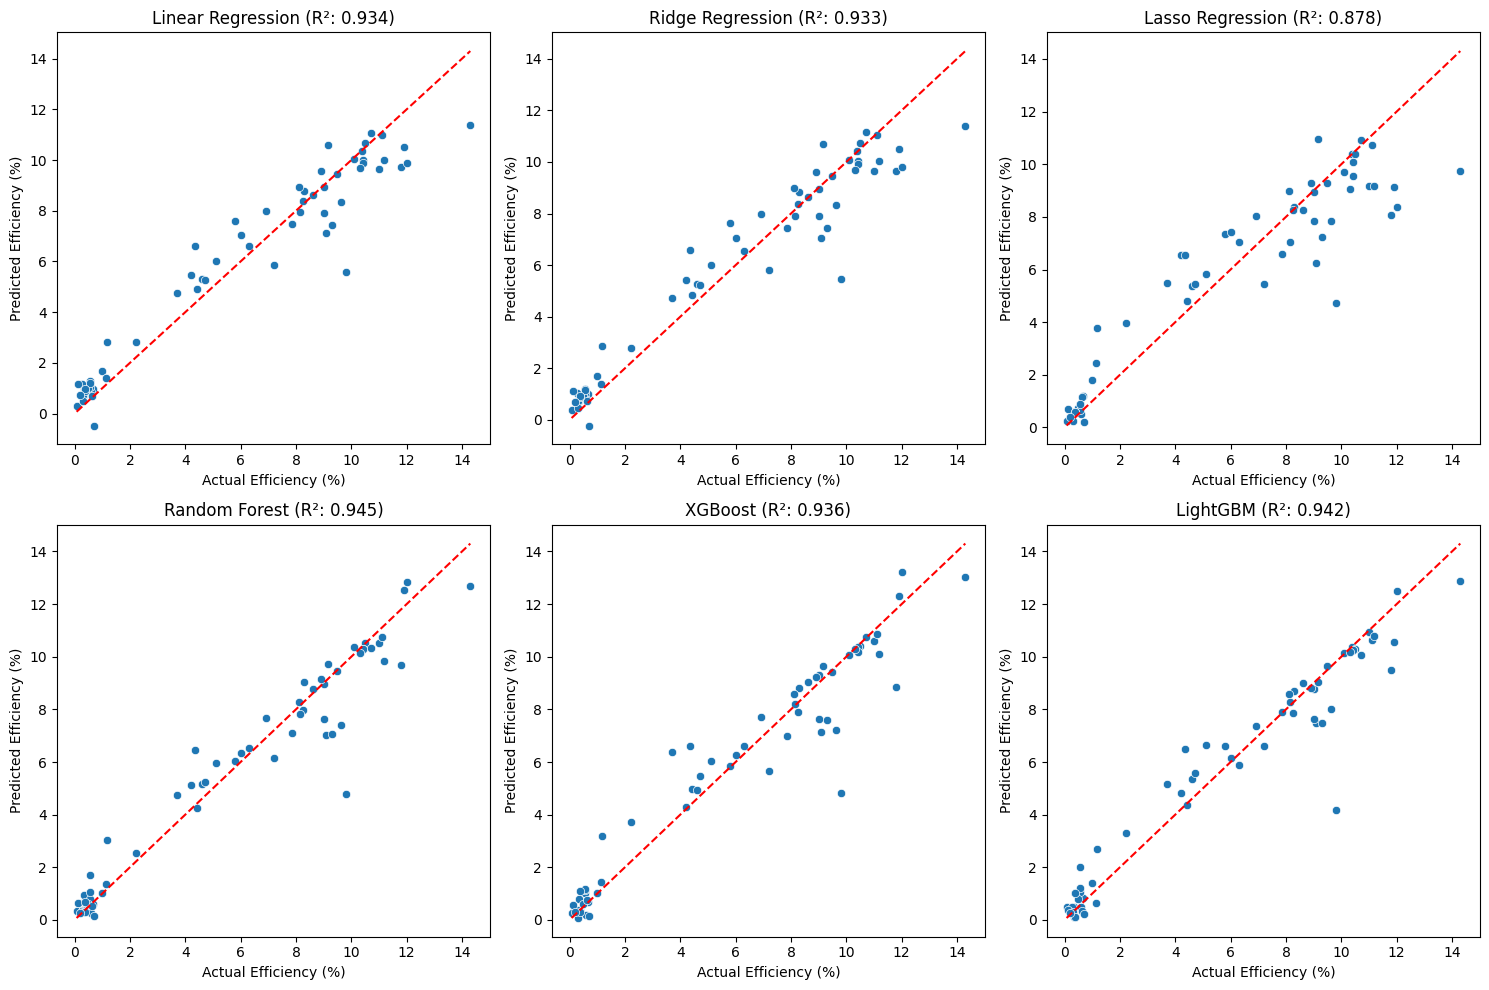

📊 Model Performance Comparison:
                   R² Score
Random Forest      0.944686
LightGBM           0.941834
XGBoost            0.935863
Linear Regression  0.933801
Ridge Regression   0.933191
Lasso Regression   0.878061
🔹 Optimal Dye-to-Pigment Ratios for Each Model:
                   Optimal Dye-to-Pigment Ratio
Linear Regression                     18.124383
Ridge Regression                      18.124383
Lasso Regression                      31.142857
Random Forest                         16.562500
XGBoost                               16.562500
LightGBM                              18.124383


<ipython-input-18-bb128b548630>:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=X_train.columns, y=importance, palette="Blues_r")


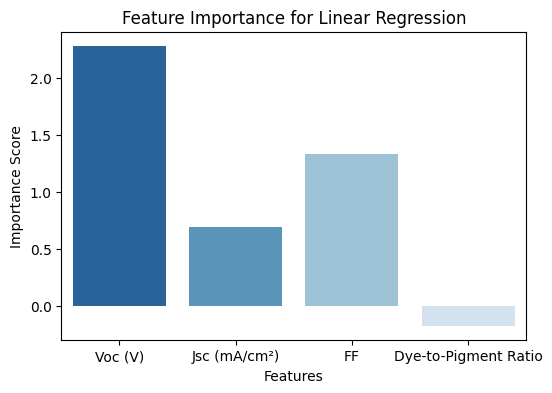

<ipython-input-18-bb128b548630>:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=X_train.columns, y=importance, palette="Blues_r")


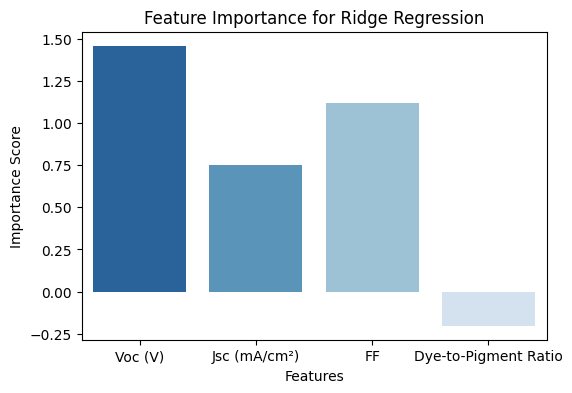

<ipython-input-18-bb128b548630>:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=X_train.columns, y=importance, palette="Blues_r")


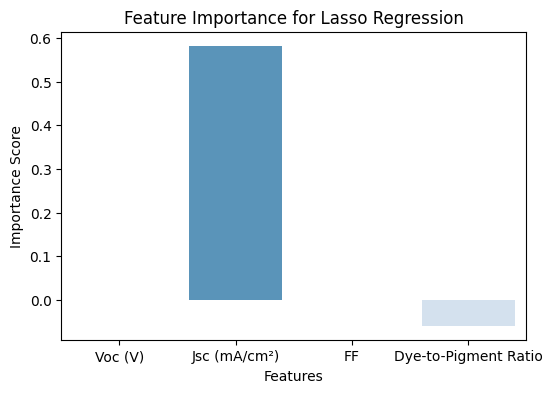

<ipython-input-18-bb128b548630>:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=X_train.columns, y=importance, palette="Blues_r")


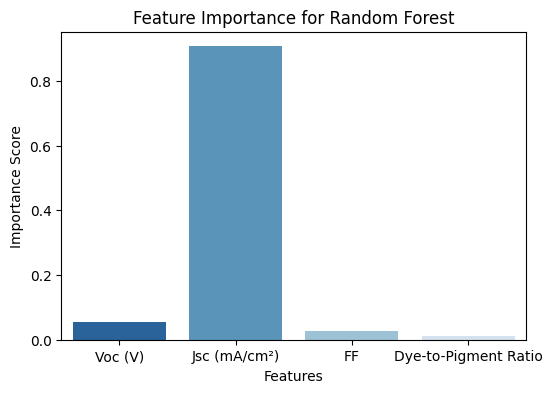

<ipython-input-18-bb128b548630>:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=X_train.columns, y=importance, palette="Blues_r")


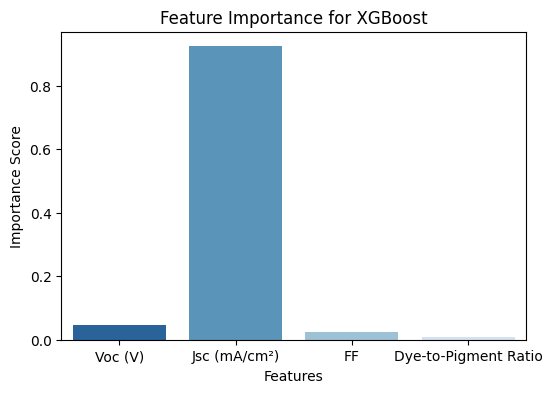

<ipython-input-18-bb128b548630>:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=X_train.columns, y=importance, palette="Blues_r")


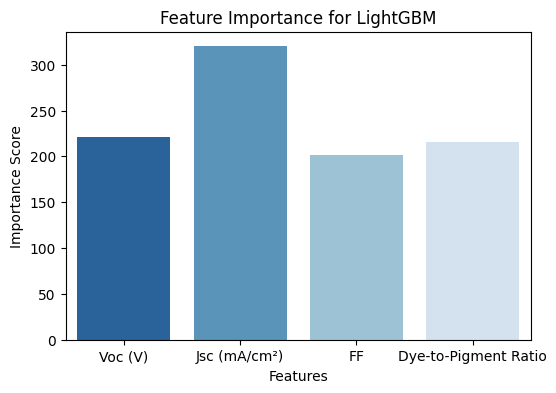

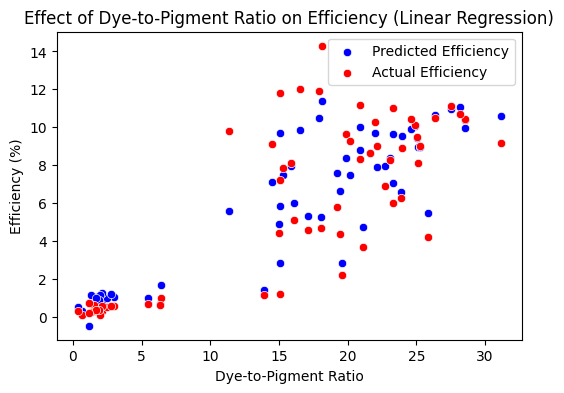

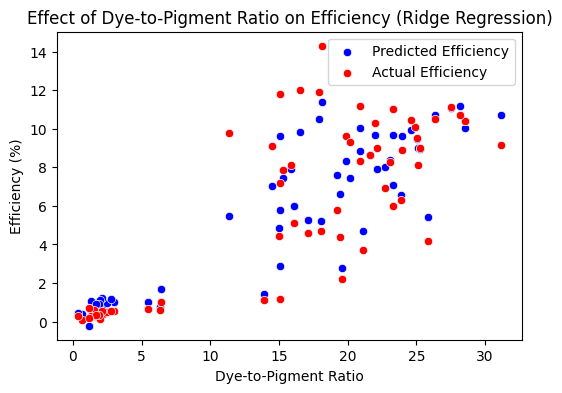

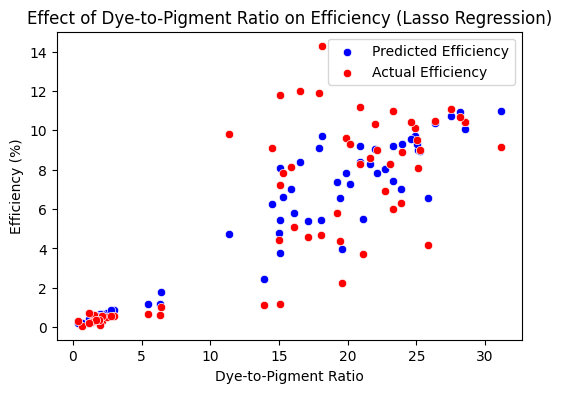

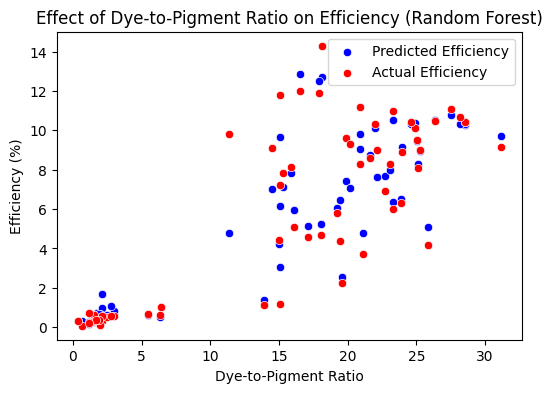

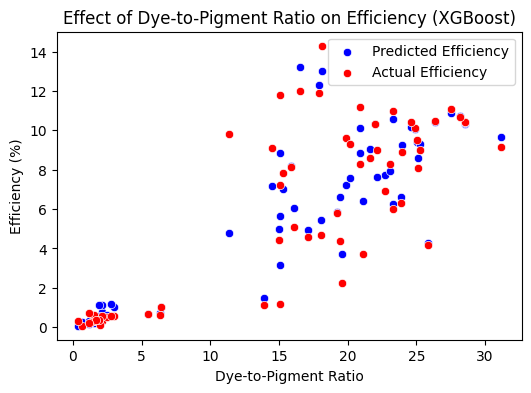

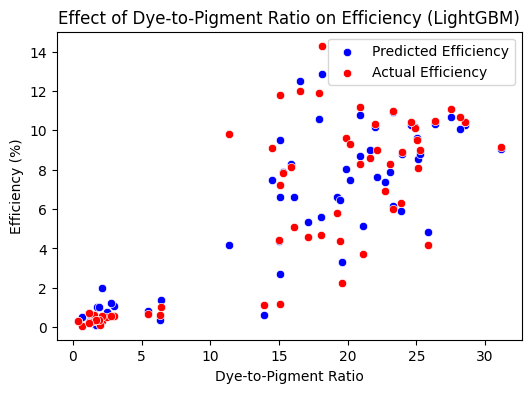

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score
import pandas as pd
import numpy as np

# Compute Dye-to-Pigment Ratio before splitting data
df["Dye-to-Pigment Ratio"] = df["Jsc (mA/cm²)"] / df["Voc (V)"]

# Define models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42)
}

# Define input features (including Dye-to-Pigment Ratio)
X = df[["Voc (V)", "Jsc (mA/cm²)", "FF", "Dye-to-Pigment Ratio"]]
y = df["Efficiency (%)"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train and evaluate each model
results = {}
optimal_ratios = {}
plt.figure(figsize=(15, 10))

for i, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    results[name] = r2

    # Find the optimal Dye-to-Pigment Ratio
    comparison_df = pd.DataFrame({"Actual Efficiency": y_test, "Predicted Efficiency": y_pred, "Dye-to-Pigment Ratio": X_test["Dye-to-Pigment Ratio"]})
    optimal_ratios[name] = comparison_df.loc[comparison_df["Predicted Efficiency"].idxmax(), "Dye-to-Pigment Ratio"]

    # Plot actual vs predicted efficiency
    plt.subplot(2, 3, i + 1)
    sns.scatterplot(x=y_test, y=y_pred)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle="--")
    plt.xlabel("Actual Efficiency (%)")
    plt.ylabel("Predicted Efficiency (%)")
    plt.title(f"{name} (R²: {r2:.3f})")

plt.tight_layout()
plt.show()

# Display model performance
results_df = pd.DataFrame.from_dict(results, orient='index', columns=["R² Score"])
print("📊 Model Performance Comparison:")
print(results_df.sort_values(by="R² Score", ascending=False))

# Display optimal Dye-to-Pigment Ratios
optimal_ratios_df = pd.DataFrame.from_dict(optimal_ratios, orient='index', columns=["Optimal Dye-to-Pigment Ratio"])
print("🔹 Optimal Dye-to-Pigment Ratios for Each Model:")
print(optimal_ratios_df)

# Feature Importance Visualization
for name, model in models.items():
    if hasattr(model, 'coef_'):
        importance = model.coef_
    elif hasattr(model, 'feature_importances_'):
        importance = model.feature_importances_
    else:
        continue

    plt.figure(figsize=(6, 4))
    sns.barplot(x=X_train.columns, y=importance, palette="Blues_r")
    plt.xlabel("Features")
    plt.ylabel("Importance Score")
    plt.title(f"Feature Importance for {name}")
    plt.show()

# Dye-to-Pigment Ratio Effect on Efficiency for Each Model
for name, model in models.items():
    y_pred = model.predict(X_test)

    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=X_test["Dye-to-Pigment Ratio"], y=y_pred, color='blue', label='Predicted Efficiency')
    sns.scatterplot(x=X_test["Dye-to-Pigment Ratio"], y=y_test, color='red', label='Actual Efficiency')
    plt.xlabel("Dye-to-Pigment Ratio")
    plt.ylabel("Efficiency (%)")
    plt.title(f"Effect of Dye-to-Pigment Ratio on Efficiency ({name})")
    plt.legend()
    plt.show()

In [ ]:
# Assuming pigment ratio is a function of Jsc and Voc
df["Dye-to-Pigment Ratio"] = df["Jsc (mA/cm²)"] / df["Voc (V)"]

# Find the ratio with the highest efficiency
optimal_ratio = df.loc[df["Efficiency (%)"].idxmax(), "Dye-to-Pigment Ratio"]

print(f"Optimal Dye-to-Pigment Ratio for Maximum Efficiency: {optimal_ratio:.2f}")


Optimal Dye-to-Pigment Ratio for Maximum Efficiency: 17.12


In [ ]:
!pip install python-docx scikit-learn matplotlib seaborn pandas numpy


In [ ]:
import pandas as pd
import docx
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


In [ ]:
# Function to extract table data from DOCX file
def extract_table_from_docx(file_path):
    doc = docx.Document(file_path)
    data = []

    for table in doc.tables:
        for i, row in enumerate(table.rows):
            if i == 0:  # Skip the header row if needed
                continue
            row_data = [cell.text.strip() for cell in row.cells]
            data.append(row_data)

    return pd.DataFrame(data)

# Path to your DOCX dataset
file_path = r"/content/drive/MyDrive/Analysis/Anuja/mmc1 (1).docx"

# Extracting data into a Pandas DataFrame
df = extract_table_from_docx(file_path)

# Rename columns for readability
df.columns = ["Dye", "Type", "Voc (V)", "Jsc (mA/cm²)", "FF", "Efficiency (%)", "DOI"]

# Convert numerical columns to appropriate types
df[["Voc (V)", "Jsc (mA/cm²)", "FF", "Efficiency (%)"]] = df[["Voc (V)", "Jsc (mA/cm²)", "FF", "Efficiency (%)"]].apply(pd.to_numeric, errors='coerce')

# Drop missing values
df.dropna(inplace=True)

# Display first few rows
df.head()


,Dye,Type,Voc (V),Jsc (mA/cm²),FF,Efficiency (%),DOI
0,N3,Metal,0.720,18.20,0.730,10.00,doi.org/10.1021/ja00067a063
1,TNCBC,Metal,0.630,13.10,0.550,6.00,10.1016/0927-0248(94)90263-1
2,TC302,Organic,0.939,7.12,0.796,5.22,10.1021/ol9022936
3,Chlorophyll,Natural,0.241,0.29,0.432,0.72,10.1088/1755-1315/144/1/012039
4,Cyanidin,Natural,0.404,1.63,0.570,0.37,10.1016/j.solmat.2006.11.005


In [ ]:
# Define input features (X) and target variable (y)
X = df[["Voc (V)", "Jsc (mA/cm²)", "FF"]]
y = df["Efficiency (%)"]

# Split data into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display dataset shape
print(f"Training Samples: {X_train.shape[0]}, Testing Samples: {X_test.shape[0]}")


Training Samples: 263, Testing Samples: 66


In [ ]:
# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)


In [ ]:
# Compute evaluation metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

# Print evaluation results
print("📊 Model Evaluation Metrics:")
print(f"✅ R² Score: {r2:.4f}")
print(f"✅ Mean Absolute Error (MAE): {mae:.4f}")
print(f"✅ Mean Squared Error (MSE): {mse:.4f}")
print(f"✅ Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"✅ Mean Absolute Percentage Error (MAPE): {mape:.2f}%")


📊 Model Evaluation Metrics:
✅ R² Score: 0.9232
✅ Mean Absolute Error (MAE): 0.9210
✅ Mean Squared Error (MSE): 1.4709
✅ Root Mean Squared Error (RMSE): 1.2128
✅ Mean Absolute Percentage Error (MAPE): 76.25%


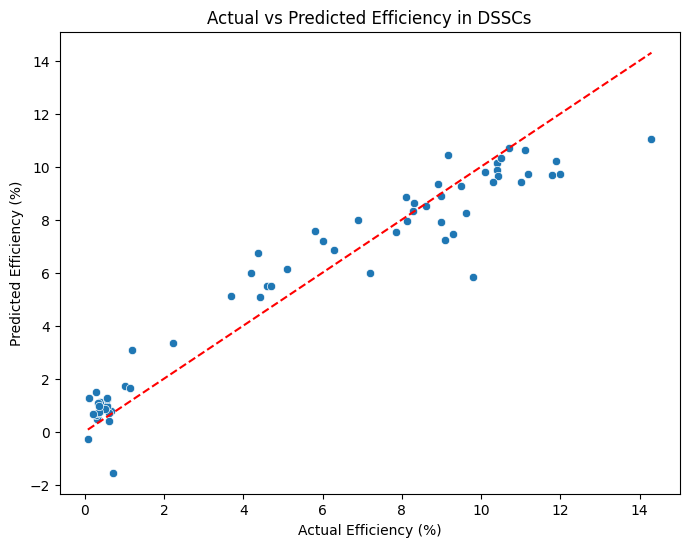

In [ ]:
# Plot actual vs predicted efficiency
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle="--")  # Diagonal line
plt.xlabel("Actual Efficiency (%)")
plt.ylabel("Predicted Efficiency (%)")
plt.title("Actual vs Predicted Efficiency in DSSCs")
plt.show()


/tmp/ipykernel_2711/3141219099.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coefficients.index, y=coefficients["Coefficient"], palette="Blues_r")


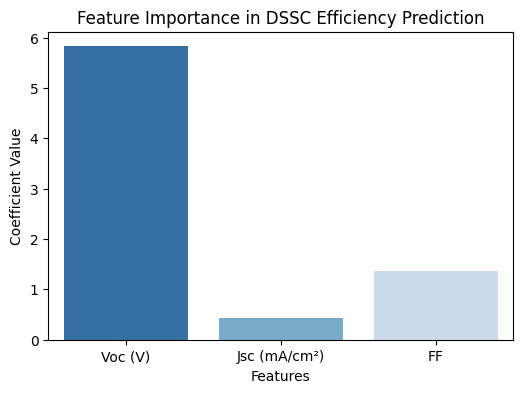

In [ ]:
# Retrieve model coefficients
coefficients = pd.DataFrame(model.coef_, X.columns, columns=["Coefficient"])

# Visualizing feature importance
plt.figure(figsize=(6,4))
sns.barplot(x=coefficients.index, y=coefficients["Coefficient"], palette="Blues_r")
plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.title("Feature Importance in DSSC Efficiency Prediction")
plt.show()


In [ ]:
# Create a new column for Dye-to-Pigment Ratio
df["Dye-to-Pigment Ratio"] = df["Jsc (mA/cm²)"] / df["Voc (V)"]

# Display sample results
df[["Dye", "Type", "Dye-to-Pigment Ratio", "Efficiency (%)"]].head()


,Dye,Type,Dye-to-Pigment Ratio,Efficiency (%)
0,N3,Metal,25.277778,10.00
1,TNCBC,Metal,20.793651,6.00
2,TC302,Organic,7.582535,5.22
3,Chlorophyll,Natural,1.203320,0.72
4,Cyanidin,Natural,4.034653,0.37


In [ ]:
df["Type"] = df["Type"].replace({
    "Orgánico": "Organic",
    "organic": "Organic",
    "metal": "Metal",
    "natural": "Natural"
})



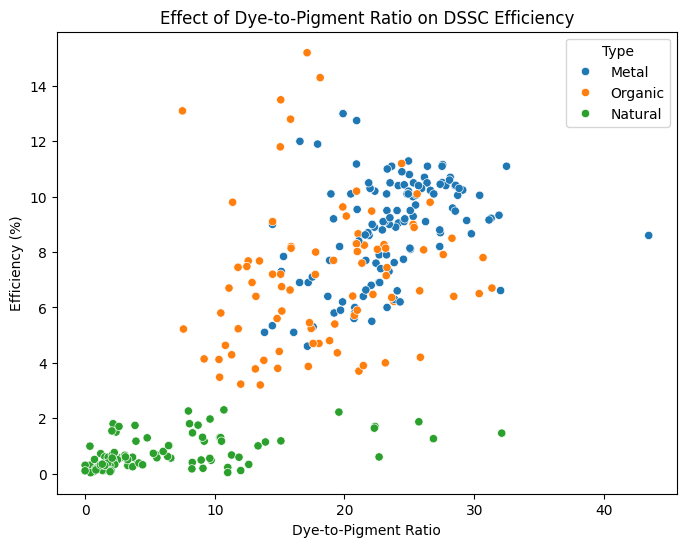

In [ ]:
# Scatter plot to visualize relationship
plt.figure(figsize=(8,6))
sns.scatterplot(x=df["Dye-to-Pigment Ratio"], y=df["Efficiency (%)"], hue=df["Type"])
plt.xlabel("Dye-to-Pigment Ratio")
plt.ylabel("Efficiency (%)")
plt.title("Effect of Dye-to-Pigment Ratio on DSSC Efficiency")
plt.show()


In [ ]:
# Find the optimal ratio corresponding to maximum efficiency
optimal_ratio = df.loc[df["Efficiency (%)"].idxmax(), "Dye-to-Pigment Ratio"]

# Print optimal ratio
print(f"🔹 The optimal dye-to-pigment ratio for maximum efficiency is: {optimal_ratio:.2f}")


🔹 The optimal dye-to-pigment ratio for maximum efficiency is: 17.12


In [ ]:
# Compute correlation coefficient
correlation = df["Dye-to-Pigment Ratio"].corr(df["Efficiency (%)"])

print(f"📊 Correlation between Dye-to-Pigment Ratio and Efficiency: {correlation:.3f}")


📊 Correlation between Dye-to-Pigment Ratio and Efficiency: 0.802


In [ ]:
!pip install python-docx scikit-learn matplotlib seaborn pandas numpy xgboost lightgbm

# Import libraries
import pandas as pd
import docx
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


In [ ]:
# Load DOCX data function
def extract_table_from_docx(file_path):
    doc = docx.Document(file_path)
    data = []

    for table in doc.tables:
        for i, row in enumerate(table.rows):
            if i == 0:  # Skip header
                continue
            row_data = [cell.text.strip() for cell in row.cells]
            data.append(row_data)

    return pd.DataFrame(data)

# Load dataset
file_path = r"/content/drive/MyDrive/Analysis/Anuja/mmc1 (1).docx"
df = extract_table_from_docx(file_path)

# Rename columns
df.columns = ["Dye", "Type", "Voc (V)", "Jsc (mA/cm²)", "FF", "Efficiency (%)", "DOI"]

# Convert numerical columns
df[["Voc (V)", "Jsc (mA/cm²)", "FF", "Efficiency (%)"]] = df[["Voc (V)", "Jsc (mA/cm²)", "FF", "Efficiency (%)"]].apply(pd.to_numeric, errors='coerce')

# Remove missing values
df.dropna(inplace=True)

# Compute Dye-to-Pigment Ratio
df["Dye-to-Pigment Ratio"] = df["Jsc (mA/cm²)"] / df["Voc (V)"]

# Display data
df.head()


,Dye,Type,Voc (V),Jsc (mA/cm²),FF,Efficiency (%),DOI,Dye-to-Pigment Ratio
0,N3,Metal,0.720,18.20,0.730,10.00,doi.org/10.1021/ja00067a063,25.277778
1,TNCBC,Metal,0.630,13.10,0.550,6.00,10.1016/0927-0248(94)90263-1,20.793651
2,TC302,Organic,0.939,7.12,0.796,5.22,10.1021/ol9022936,7.582535
3,Chlorophyll,Natural,0.241,0.29,0.432,0.72,10.1088/1755-1315/144/1/012039,1.203320
4,Cyanidin,Natural,0.404,1.63,0.570,0.37,10.1016/j.solmat.2006.11.005,4.034653


In [ ]:
# Define input features (X) and target variable (y)
X = df[["Voc (V)", "Jsc (mA/cm²)", "FF", "Dye-to-Pigment Ratio"]]
y = df["Efficiency (%)"]

# Split data into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display dataset size
print(f"Training Samples: {X_train.shape[0]}, Testing Samples: {X_test.shape[0]}")


Training Samples: 263, Testing Samples: 66


In [ ]:
# Define models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42)
}

# Train and evaluate each model
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results[name] = {"R² Score": r2, "MAE": mae, "RMSE": rmse}

# Convert results to DataFrame
results_df = pd.DataFrame(results).T

# Display model performance
print("📊 Model Performance Comparison:")
print(results_df)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000042 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 261
[LightGBM] [Info] Number of data points in the train set: 263, number of used features: 4
[LightGBM] [Info] Start training from score 5.524464
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

In [ ]:
# Sort models based on R² score
best_model_name = results_df["R² Score"].idxmax()
best_model = models[best_model_name]

print(f"✅ Best Model: {best_model_name} with R² Score = {results_df.loc[best_model_name, 'R² Score']:.4f}")


✅ Best Model: Random Forest with R² Score = 0.9447


In [ ]:
# Predict efficiency using the best model
y_pred_best = best_model.predict(X_test)

# Compare actual vs predicted efficiency
comparison_df = pd.DataFrame({"Actual Efficiency": y_test, "Predicted Efficiency": y_pred_best, "Dye-to-Pigment Ratio": X_test["Dye-to-Pigment Ratio"]})

# Find the best ratio for highest predicted efficiency
optimal_ratio_ml = comparison_df.loc[comparison_df["Predicted Efficiency"].idxmax(), "Dye-to-Pigment Ratio"]

print(f"🔹 Optimized Dye-to-Pigment Ratio (ML-based): {optimal_ratio_ml:.2f}")


🔹 Optimized Dye-to-Pigment Ratio (ML-based): 16.56


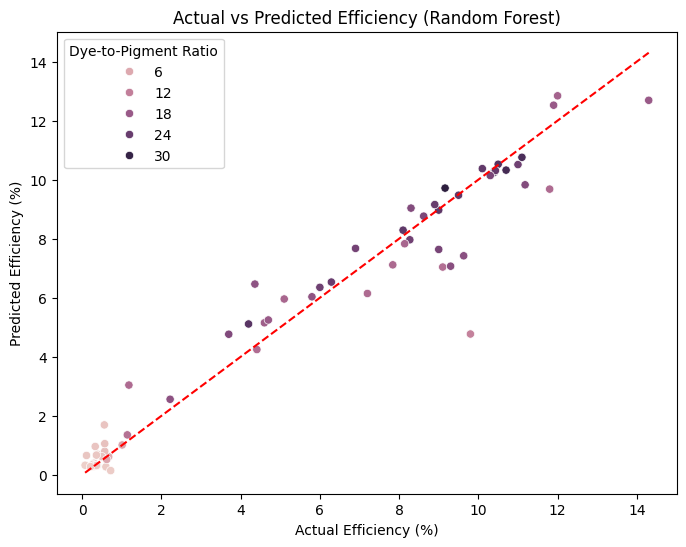

In [ ]:
# Plot actual vs predicted efficiency
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred_best, hue=X_test["Dye-to-Pigment Ratio"])
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle="--")  # Diagonal line
plt.xlabel("Actual Efficiency (%)")
plt.ylabel("Predicted Efficiency (%)")
plt.title(f"Actual vs Predicted Efficiency ({best_model_name})")
plt.show()


<ipython-input-32-eda8ad925da7>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance["Feature"], y=feature_importance["Importance"], palette="Blues_r")


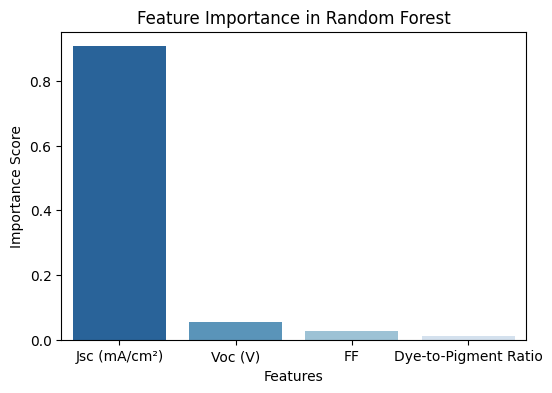

In [ ]:
# Feature importance for RandomForest, XGBoost, or LightGBM
if best_model_name in ["Random Forest", "XGBoost", "LightGBM"]:
    feature_importance = pd.DataFrame({"Feature": X.columns, "Importance": best_model.feature_importances_}).sort_values(by="Importance", ascending=False)

    # Plot feature importance
    plt.figure(figsize=(6,4))
    sns.barplot(x=feature_importance["Feature"], y=feature_importance["Importance"], palette="Blues_r")
    plt.xlabel("Features")
    plt.ylabel("Importance Score")
    plt.title(f"Feature Importance in {best_model_name}")
    plt.show()


📊 Model Predictions vs. Experimental Data:
     Actual Efficiency  Predicted Efficiency  Dye-to-Pigment Ratio    Error
9                10.40              10.24840             28.513889  0.15160
164               0.38               0.32214              1.630252  0.05786
139               8.30               9.03740             20.897436  0.73740
46               10.50              10.52240             26.363636  0.02240
94                9.63               7.42130             19.870130  2.20870


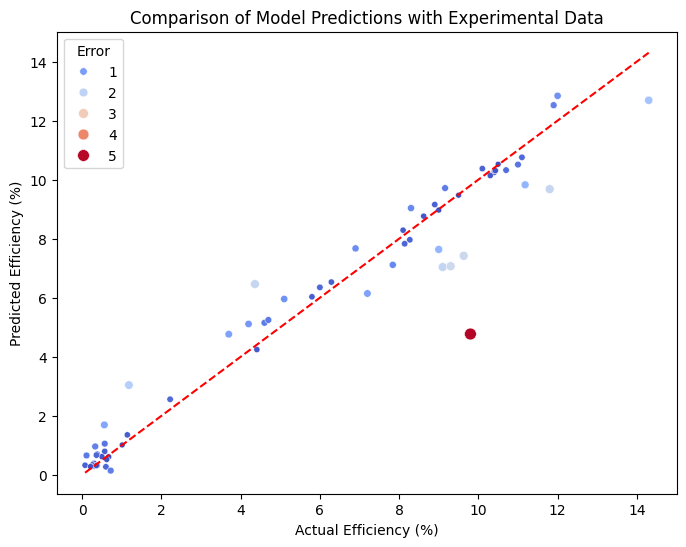

In [ ]:
# Compare actual efficiency vs. predicted efficiency from the best model
comparison_df["Error"] = abs(comparison_df["Actual Efficiency"] - comparison_df["Predicted Efficiency"])

# Display the first few comparisons
print("📊 Model Predictions vs. Experimental Data:")
print(comparison_df.head())

# Plot Actual vs. Predicted Efficiency with Errors
plt.figure(figsize=(8,6))
sns.scatterplot(x=comparison_df["Actual Efficiency"], y=comparison_df["Predicted Efficiency"], hue=comparison_df["Error"], palette="coolwarm", size=comparison_df["Error"])
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle="--")  # Perfect prediction line
plt.xlabel("Actual Efficiency (%)")
plt.ylabel("Predicted Efficiency (%)")
plt.title("Comparison of Model Predictions with Experimental Data")
plt.show()


In [ ]:
from sklearn.model_selection import GridSearchCV

# Check which model needs tuning
if best_model_name == "Random Forest":
    param_grid = {
        "n_estimators": [100, 200, 300],
        "max_depth": [3, 5, 7],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    }

elif best_model_name in ["XGBoost", "LightGBM"]:
    param_grid = {
        "n_estimators": [100, 200, 300],
        "max_depth": [3, 5, 7],
        "learning_rate": [0.01, 0.1, 0.2]
    }

# Run GridSearchCV
grid_search = GridSearchCV(best_model, param_grid, cv=5, scoring="r2", n_jobs=-1)
grid_search.fit(X_train, y_train)

# Get the best parameters
best_params = grid_search.best_params_
print(f"🎯 Optimized Parameters for {best_model_name}: {best_params}")

# Train best model with optimized parameters
best_model = best_model.set_params(**best_params)
best_model.fit(X_train, y_train)

# Predict again with the optimized model
y_pred_best = best_model.predict(X_test)

# Update comparison DataFrame
comparison_df["Optimized Prediction"] = y_pred_best


🎯 Optimized Parameters for Random Forest: {'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Define ANN model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')  # Output layer for efficiency prediction
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.01), loss='mse', metrics=['mae'])

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_test, y_test), verbose=0)

# Predict using the trained ANN
y_pred_ann = model.predict(X_test).flatten()

# Compare ANN results with traditional ML
comparison_df["ANN Prediction"] = y_pred_ann

# ANN Model Evaluation
ann_r2 = r2_score(y_test, y_pred_ann)
ann_mae = mean_absolute_error(y_test, y_pred_ann)

print(f"✅ ANN Model Performance: R² = {ann_r2:.4f}, MAE = {ann_mae:.4f}")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
✅ ANN Model Performance: R² = 0.9537, MAE = 0.5785


📊 Final Model Performance Comparison:
                                 R² Score       MAE      RMSE
Linear Regression                0.933801  0.840644  1.126329
Ridge Regression                 0.933191  0.834154  1.131506
Lasso Regression                 0.878061  1.043936  1.528660
Random Forest                    0.944686  0.628933  1.029571
XGBoost                          0.935863  0.670969  1.108651
LightGBM                         0.941834  0.646574  1.055777
Artificial Neural Network (ANN)  0.953714  0.578471  0.941814


<ipython-input-36-7d213374dda4>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df["R² Score"], palette="coolwarm")


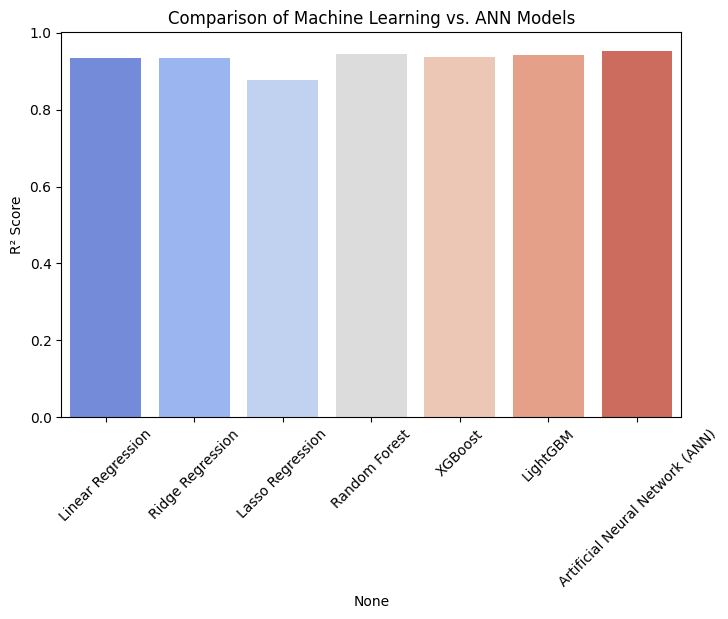

In [ ]:
# Compare results of ML and ANN models
results_df.loc["Artificial Neural Network (ANN)"] = [ann_r2, ann_mae, np.sqrt(mean_squared_error(y_test, y_pred_ann))]

# Display model performance comparison
print("📊 Final Model Performance Comparison:")
print(results_df)

# Plot model comparison
plt.figure(figsize=(8,5))
sns.barplot(x=results_df.index, y=results_df["R² Score"], palette="coolwarm")
plt.ylabel("R² Score")
plt.title("Comparison of Machine Learning vs. ANN Models")
plt.xticks(rotation=45)
plt.show()


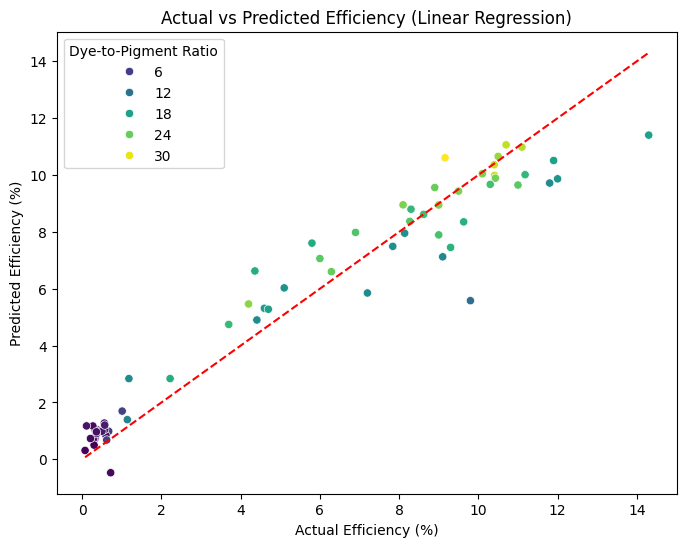

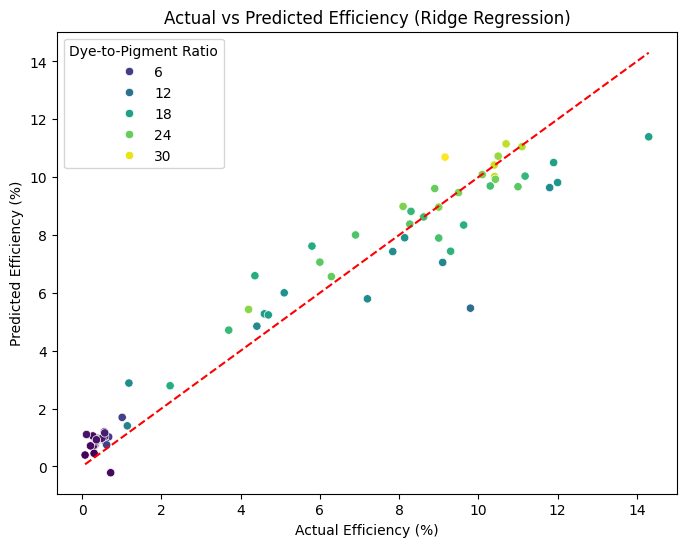

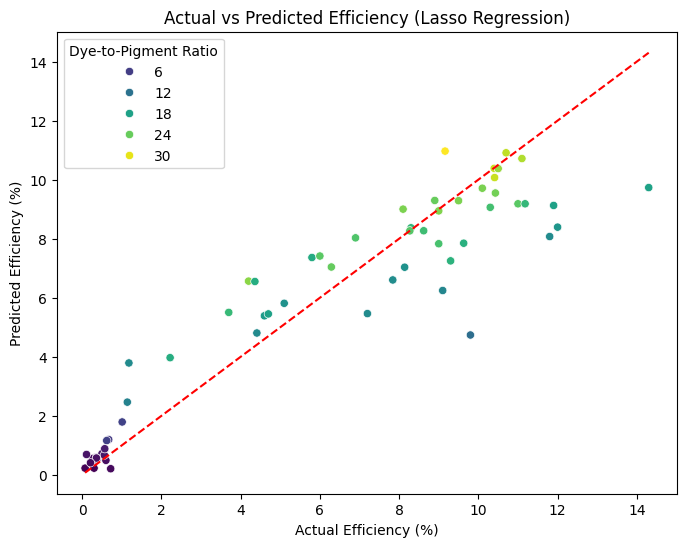

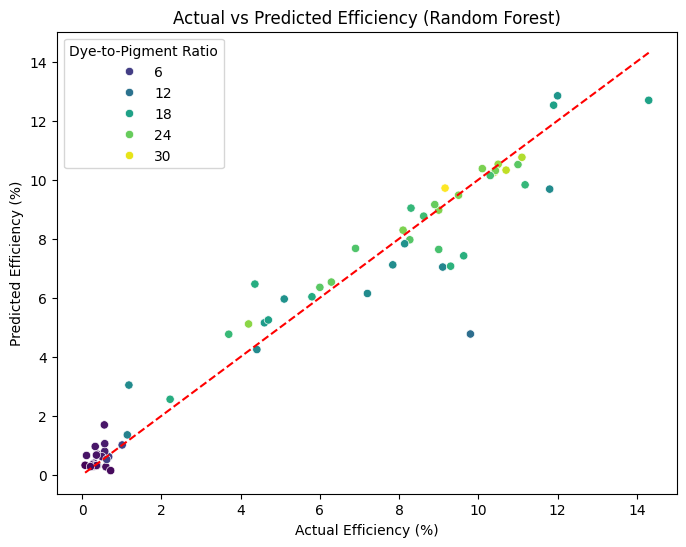

/tmp/ipykernel_1537/2357935021.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance["Feature"], y=feature_importance["Importance"], palette="Blues_r")


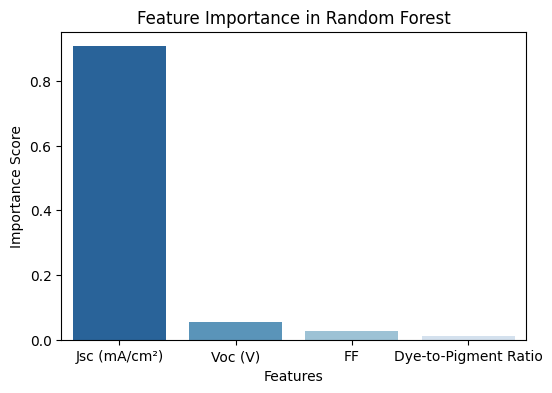

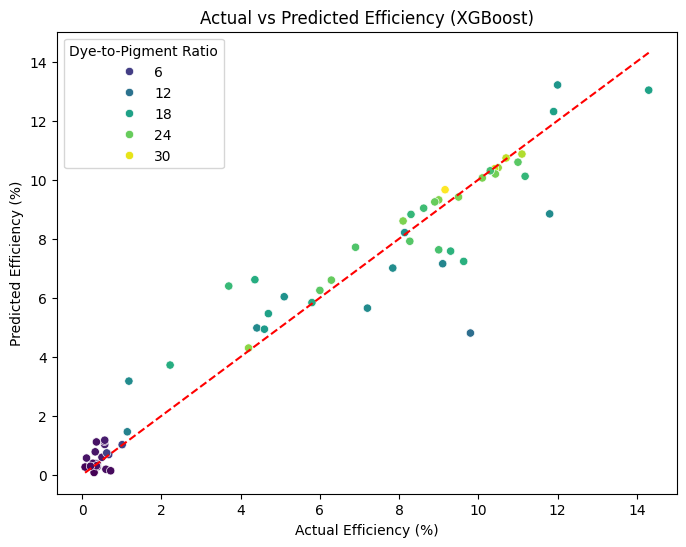

/tmp/ipykernel_1537/2357935021.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance["Feature"], y=feature_importance["Importance"], palette="Blues_r")


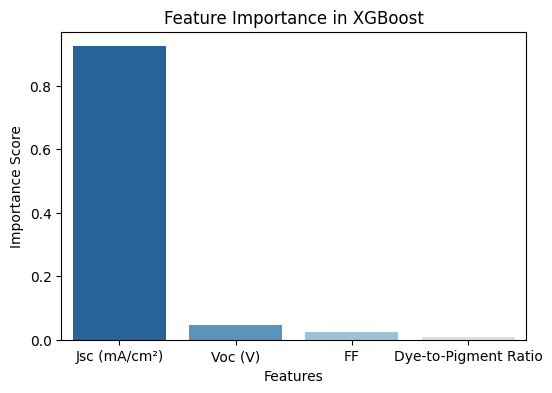

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000139 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 261
[LightGBM] [Info] Number of data points in the train set: 263, number of used features: 4
[LightGBM] [Info] Start training from score 5.524464
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

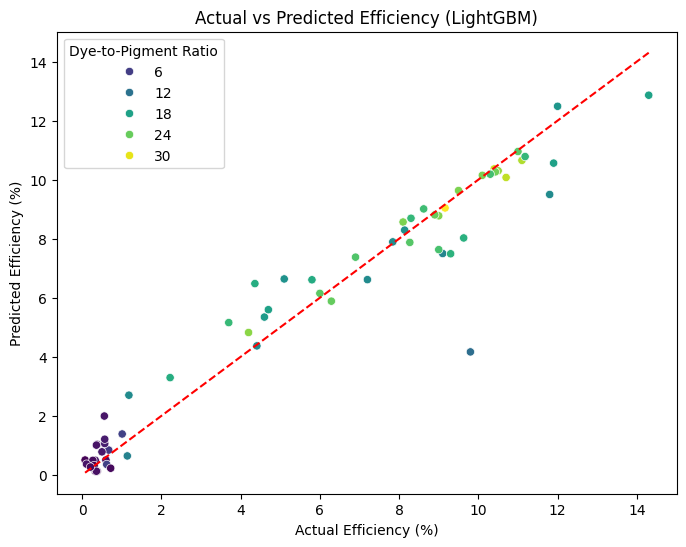

/tmp/ipykernel_1537/2357935021.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance["Feature"], y=feature_importance["Importance"], palette="Blues_r")


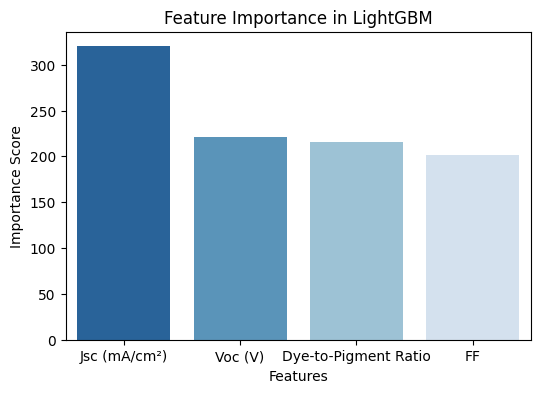

📊 Model Performance Comparison:
                   R² Score       MAE      RMSE
Linear Regression  0.933801  0.840644  1.126329
Ridge Regression   0.933191  0.834154  1.131506
Lasso Regression   0.878061  1.043936  1.528660
Random Forest      0.944686  0.628933  1.029571
XGBoost            0.935863  0.670969  1.108651
LightGBM           0.941834  0.646574  1.055777


In [ ]:
import docx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Load DOCX data function
def extract_table_from_docx(file_path):
    doc = docx.Document(file_path)
    data = []

    for table in doc.tables:
        for i, row in enumerate(table.rows):
            if i == 0:
                continue
            row_data = [cell.text.strip() for cell in row.cells]
            data.append(row_data)

    return pd.DataFrame(data)

# Load dataset
file_path = r"/content/drive/MyDrive/Analysis/Anuja/mmc1 (1).docx"
df = extract_table_from_docx(file_path)

# Rename columns
df.columns = ["Dye", "Type", "Voc (V)", "Jsc (mA/cm²)", "FF", "Efficiency (%)", "DOI"]

# Convert numerical columns
df[["Voc (V)", "Jsc (mA/cm²)", "FF", "Efficiency (%)"]] = df[["Voc (V)", "Jsc (mA/cm²)", "FF", "Efficiency (%)"]].apply(pd.to_numeric, errors='coerce')

# Remove missing values
df.dropna(inplace=True)

# Compute Dye-to-Pigment Ratio
df["Dye-to-Pigment Ratio"] = df["Jsc (mA/cm²)"] / df["Voc (V)"]

# Define input features (X) and target variable (y)
X = df[["Voc (V)", "Jsc (mA/cm²)", "FF", "Dye-to-Pigment Ratio"]]
y = df["Efficiency (%)"]

# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42)
}

# Train, evaluate models, and store results
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results[name] = {"R² Score": r2, "MAE": mae, "RMSE": rmse}

    # Scatter plot for actual vs predicted efficiency
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=y_test, y=y_pred, hue=X_test["Dye-to-Pigment Ratio"], palette="viridis")
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle="--")
    plt.xlabel("Actual Efficiency (%)")
    plt.ylabel("Predicted Efficiency (%)")
    plt.title(f"Actual vs Predicted Efficiency ({name})")
    plt.show()

    # Feature importance for tree-based models
    if name in ["Random Forest", "XGBoost", "LightGBM"]:
        feature_importance = pd.DataFrame({"Feature": X.columns, "Importance": model.feature_importances_}).sort_values(by="Importance", ascending=False)
        plt.figure(figsize=(6,4))
        sns.barplot(x=feature_importance["Feature"], y=feature_importance["Importance"], palette="Blues_r")
        plt.xlabel("Features")
        plt.ylabel("Importance Score")
        plt.title(f"Feature Importance in {name}")
        plt.show()

# Convert results to DataFrame
results_df = pd.DataFrame(results).T
print("📊 Model Performance Comparison:")
print(results_df)

In [ ]:
from scipy.signal import savgol_filter
from scipy.stats import zscore
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
# Remove missing values
df.dropna(inplace=True)

# Compute Dye-to-Pigment Ratio
df["Dye-to-Pigment Ratio"] = df["Jsc (mA/cm²)"] / df["Voc (V)"]
# =====================================================
# Remove Missing Values
# =====================================================

df.dropna(inplace=True)

print("="*60)
print("Original Experimental Samples :", len(df))
print("="*60)

# =====================================================
# Champion Cell Protection (Top 5% Efficiency)
# =====================================================

champion_threshold = df["Efficiency (%)"].quantile(0.95)

champion_mask = df["Efficiency (%)"] >= champion_threshold

print("Champion Cells :", champion_mask.sum())

# =====================================================
# IQR Outlier Detection
# =====================================================

numeric_cols = ["Voc (V)", "Jsc (mA/cm²)", "FF", "Efficiency (%)"]

Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

iqr_mask = ~(
    ((df[numeric_cols] < (Q1 - 1.5 * IQR)) |
     (df[numeric_cols] > (Q3 + 1.5 * IQR)))
).any(axis=1)

print("Samples Flagged by IQR :", len(df)-iqr_mask.sum())

# =====================================================
# Z-score Detection
# =====================================================

z_scores = np.abs(zscore(df[numeric_cols]))

z_mask = (z_scores < 3).all(axis=1)

print("Samples Flagged by Z-score :", len(df)-z_mask.sum())

# =====================================================
# Combined Rule
# Remove only when BOTH methods identify an outlier
# Champion cells are preserved
# =====================================================

remove_mask = (~iqr_mask) & (~z_mask)

remove_mask = remove_mask & (~champion_mask)

print("Final Samples Removed :", remove_mask.sum())

df = df.loc[~remove_mask].reset_index(drop=True)

print("Remaining Samples :", len(df))

# =====================================================
# Savitzky-Golay Smoothing
# =====================================================

WINDOW_LENGTH = 5
POLY_ORDER = 2

for col in numeric_cols:
    df[col] = savgol_filter(
        df[col],
        window_length=WINDOW_LENGTH,
        polyorder=POLY_ORDER
    )

print("="*60)
print("Savitzky-Golay Applied")
print("Window Length :", WINDOW_LENGTH)
print("Polynomial Order :", POLY_ORDER)
print("="*60)

# =====================================================
# Feature Engineering
# =====================================================

df["Dye-to-Pigment Ratio"] = df["Jsc (mA/cm²)"] / df["Voc (V)"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

print("="*60)
print("Training Samples :", len(X_train))
print("Testing Samples :", len(X_test))
print("="*60)
model.fit(X_train, y_train)
# ===============================================
# 5-Fold Cross Validation
# ===============================================

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=kf,
    scoring="r2"
)

print(f"{name} 5-Fold CV R² : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Original Experimental Samples : 329
Champion Cells : 18
Samples Flagged by IQR : 31
Samples Flagged by Z-score : 6
Final Samples Removed : 6
Remaining Samples : 323
Savitzky-Golay Applied
Window Length : 5
Polynomial Order : 2
Training Samples : 263
Testing Samples : 66
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000041 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 261
[LightGBM] [Info] Number of data points in the train set: 263, number of used features: 4
[LightGBM] [Info] Start training from score 5.524464
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] 